### This is a data processing example script for the Binge Feeding paper (Lo et al., Neuron 2025) 
This python script is used for:
- process behavioral data (phenosys csv file) for food delivery timestamps and define binge feeding and slow feeding events
- process miniscope Ca2+ imaging data (merge several csv files from different FoVs, downsample, baseline correction, z-score)
- align Ca2+ imaging data to the behavioral data
- compute PETH for food and water deliveries
- classify neurons into food/water responding neurons using auROC
- compare neuronal responses for slow feeding and binge feeding.

Other statistical analysis (q value calculation, cohen's d calculation, pearson's correlation coefficient, linear mixed model...etc) are excluded in this example code.

In [1]:
## import packages

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
import datetime
import numpy as np
import pandas as pd
from BaselineRemoval import BaselineRemoval
import pynapple as nap
from scipy import stats
%config InlineBackend.figure_format = 'retina' # to increase fig dpi


In [2]:
## plotting settings

## create color map
my_color_map = ['#56b4e9',
                '#e69f00',
                '#009e73',
                '#f0e442',
                '#0072b2',
                '#d55e00',
                '#cc79a7']
# convert to sns plotting rgb
my_color_map = sns.color_palette(my_color_map)

# 20% lighter 
my_color_map_grey_light = ['#B3B3B3',
                      '#89E7FF',
                      '#FFB91A',
                      '#33D1A6',
                      '#FFFF75',
                      '#33A5E5',
                      '#FF9133',
                      '#FFACDA']
my_color_map_grey_light = sns.color_palette(my_color_map_grey_light)

my_color_map_grey = ['#808080',
                      '#56b4e9',
                      '#e69f00',
                      '#009e73',
                      '#f0e442',
                      '#0072b2',
                      '#d55e00',
                      '#cc79a7']
# convert to sns plotting rgb
my_color_map_grey = sns.color_palette(my_color_map_grey)

color_map_black_grey = ['#000000','#808080']
color_map_black_grey = sns.color_palette(color_map_black_grey)

## font setting
plt.rcParams["font.family"] = 'Arial'
plt.rcParams.update({'font.size': 8})

def save_plot_pdf(plot_name):
    fig_output_folder = '/Users/hunglo/Documents/inscopix_csv/fig_output/'
    kwargs = {"facecolor":"white","dpi":300,"bbox_inches":"tight"}
    # kwargs = {"facecolor":"white","dpi":300} # no tight arg here, to prevent fontsize changes
    plt.savefig(f'{fig_output_folder}{plot_name}.pdf',**kwargs)

def get_auto_colors(n_colors):
    auto_color_map_cat = sns.color_palette("husl", n_colors)
    return auto_color_map_cat

def correct_baseline_modploy(df_accepted):
    input_array = df_accepted.values
    polynomial_degree=2 #only needed for Modpoly and IModPoly algorithm
    baseObj=BaselineRemoval(input_array)
    Modpoly_output=baseObj.ModPoly(polynomial_degree)
    df_corrected = pd.DataFrame(data=Modpoly_output,index=df_accepted.index,columns=[' C1'])
    return df_corrected

def load_mouse_info_from_meta_data():
  import pandas as pd
  # import chardet
  filename = '/Users/hunglo/Documents/inscopix_csv/Recordings_overview_updated_old.csv'

  df_overview = pd.read_csv(filename,skiprows=2)
  df_overview = df_overview[df_overview['Imaging?']==True] ## Only load those sessions with recordings.
  mouse_id_list = df_overview['Mouse ID'].unique()
  mouse_id_list = mouse_id_list[~pd.isnull(mouse_id_list)]
  mouse_id_list = sorted(mouse_id_list)
  return df_overview, mouse_id_list

def get_metadata(mouse_id, date):
    df_overview, _ = load_mouse_info_from_meta_data()
    select_overview = df_overview[df_overview['Mouse ID'] == mouse_id].copy()
    select_overview = select_overview[select_overview['Recording date']=='20'+date]


    Pump1_solution = select_overview['Flavor 1'].to_numpy()[0].lower()
    Pump2_solution = select_overview['Flavor 2'].to_numpy()[0].lower()
    Food_deprivation = select_overview['Food_deprived'].to_numpy()[0].lower()
    if 'OFC' in select_overview['Genotype'].to_numpy()[0]:
        Genotype = 'OFC' # make this condition first, so that OFC won't be classified as just CaMK2
    elif 'CaMK2a' in select_overview['Genotype'].to_numpy()[0]:
        Genotype = 'CaMK2'
    elif 'iSeroSnFR' in select_overview['Genotype'].to_numpy()[0]:
        Genotype = 'iSeroSnFR'
    elif 'dLight' in select_overview['Genotype'].to_numpy()[0]:
        Genotype = 'dLight'
    elif 'S2GC' in select_overview['Genotype'].to_numpy()[0]:
        Genotype = 'S2GC'
    elif 'S2' in select_overview['Genotype'].to_numpy()[0]:
        Genotype = 'S2'
    elif 'GC' in select_overview['Genotype'].to_numpy()[0]:
        Genotype = 'GC'
    else:
        Genotype = select_overview['Genotype'].to_numpy()[0]
    mouse_name = select_overview['Mouse Name'].to_numpy()[0]
    
    return Pump1_solution, Pump2_solution, Food_deprivation, Genotype, mouse_name

df_overview, mouse_id_list = load_mouse_info_from_meta_data()
df_overview.head()



,Mouse Name,Mouse ID,Genotype,Tg/viral,Session,Recording date,Body_weight,Food_intake_before,Food_intake_after,Food_deprived,...,Imaging?,Flavor 1,Flavor 2,Total_deliveries,Comment,CNMFe processed,Data curation,auROC quality,Used for presentation,Used for publication
1,Karl-Heinz Leopold,BES0224,CaMK2a-cre; Ai93D,Tg,2,2020.08.07,36.00,4.00,NaN,Mild,...,True,Strawberry,Water,0.0,NaN,done,NaN,Empty,NaN,NaN
2,Karl-Heinz Leopold,BES0224,CaMK2a-cre; Ai93D,Tg,3,2020.08.11,34.13,NaN,4.27,Mild,...,True,Strawberry,Water,5.0,NaN,done,NaN,NaN,NaN,NaN
3,Karl-Heinz Leopold,BES0224,CaMK2a-cre; Ai93D,Tg,4,2020.08.12,33.69,4.27,4.06,Mild,...,True,Strawberry,Water,0.0,NaN,done,NaN,Empty,NaN,NaN
4,Karl-Heinz Leopold,BES0224,CaMK2a-cre; Ai93D,Tg,5,2020.08.13,33.47,4.06,3.86,Mild,...,True,Strawberry,Water,0.0,NaN,done,NaN,NaN,NaN,NaN
5,Karl-Heinz Leopold,BES0224,CaMK2a-cre; Ai93D,Tg,6,2020.08.14,33.24,3.86,4.73,Mild,...,True,Strawberry,Water,0.0,NaN,done,NaN,Empty,NaN,NaN


In [3]:
### function block, need to move to "binge.py" later, but will keep them here

##### functions for data processing #####

def norm_ca(df):
    df_norm = pd.DataFrame([])
    for idx,cell in enumerate(df.columns):
        ## normalize to 0-1
        df_max=np.max(df[cell])
        df_min=np.min(df[cell])
        df_norm[cell] = (df[cell]-df_min)/(df_max-df_min)
    return df_norm

def ca2_plot(df,scale=5,cell_idx=None,**kwargs):
    ## scale here is just to help viz
    if cell_idx == None:
        for idx,cell in enumerate(df.columns):
            plt.plot(df[cell]*scale+idx,lw=1,**kwargs)
    else:
        for idx,cell_ in enumerate(list(cell_idx)):
            ## normalize to 0-1
            cell = df.columns[idx]
            plt.plot(df[cell]*scale+idx,lw=1,**kwargs)

 
# def detect_binge_bout(Pump1,interval=3):
#     """
#     this is a old one
#     """
#     Pump1 = np.pad(Pump1, (1, 1), 'constant', constant_values=(0,Pump1.max()+interval*10)) # so the last value is more than interval
#     diff = Pump1[1:]-Pump1[:-1]
#     gap = diff>interval # binary data
#     idx = np.where(gap == 1) # idx == 1
#     start_concat, end_concat = [],[]
#     for idx_ in idx:
#         start_concat.append(Pump1[1:][idx_])
#         end_concat.append(Pump1[:][idx_])
#     start_concat = start_concat[0][:-1] # remove empty starting
#     end_concat = end_concat[0][1:] # remove empty ending

#     binge_epoch = nap.IntervalSet(start_concat,end_concat)

#     ## run through the rows to make sure there isn't no duration epochs
#     ## note this should be taken care of from the pynapple package but somehow it isn't working properly 
#     binge_epoch_clean = pd.DataFrame(data=[], columns=['start','end'])
#     for n in range(binge_epoch.shape[0]):
#         for x,y in binge_epoch[n:n+1].values:
#             # print(x,y)
#             # if x!= y: ## this is the old alg
#             if y-x >3: # at least 3 sec bout
#             # if True:
#                 binge_epoch_clean = pd.concat([binge_epoch_clean,binge_epoch[n:n+1]])
#     binge_epoch_clean = nap.IntervalSet(binge_epoch_clean['start'],binge_epoch_clean['end'], time_units='s')
#     return binge_epoch_clean

## burst detection function from other ppl, adapted from the following link
## https://spikesandbursts.wordpress.com/2023/08/24/patch-clamp-data-analysis-in-python-bursts/
def burst_detection(df, spike_times,
                    n_spikes, 
                    max_isi, 
                    # min_duration,  # Optional
                    min_ibi):
     
    """
    Detects bursts in spike data based on spike times, 
    by identifying consecutive spikes that fulfill the criteria of:
    minimum number of spikes, maximum interspike interval, and minimum interburst interval.
     
    Arguments: 
        df: DataFrame with spike data.
        spike_times: Column name for spike positions.
        spike_amplitudes: Column name for spike amplitudes.
        spike_peaks: Column name for spike peak amplitudes. 
        n_spikes: Minimum number of spikes within a burst.
        max_isi: Max interspike interval within the burst.
        min_duration: Minimum burst duration.
        min_ibi: Minimum interburst interval (optional).
         
    Returns:
        DataFrame with burst information.
    """
     
    df = df.sort_values(by=spike_times)  # Sort DataFrame by spike positions
    df['burst'] = np.nan  # Create column for burst labels
    burst_num = 0        # Initialize burst number
    burst_start = None   # Initialize burst start position
    last_spike = None    # Initialize last spike position
 
    for i, row in df.iterrows():  # Loop through DataFrame rows 
        spike = row[spike_times]   # Extract the spike position 
         
        if burst_start is None:   # It checks if it is the first spike 
            burst_start = spike   # It marks the current spike position as the start of a burst
            last_spike = spike    # Update the last_spike position to the current spike position
            df.at[i, 'burst'] = burst_num   # Assign burst number
        elif spike - last_spike <= max_isi:  # It checks if the current spike is within max isi
            df.at[i, 'burst'] = burst_num  
            last_spike = spike 
        elif spike - last_spike > min_ibi:  # It checks if the interburst interval has been reached
            burst_num += 1 
            burst_start = spike 
            last_spike = spike  
            df.at[i, 'burst'] = burst_num
     
    # Filter bursts with less than min_spikes
    df = df[df.groupby('burst')[spike_times].transform('count') >= n_spikes]
     
    # Filter burst shorter that min_duration (min_duration parameter)
    # df = df[df.groupby('burst')[spike_times].transform('max') 
    #         - df.groupby('burst')[spike_times].transform('min')
    #         >= min_duration]
     
    # Calculate burst information by aggregating single spike information
    bursts = df.groupby('burst')[spike_times].agg(['min', 'max', 'count'])
    bursts.columns = ['burst_start', 'burst_end', 'spikes_in_bursts']
    bursts['burst_length'] = bursts['burst_end'] - bursts['burst_start']
    # bursts['avg_spike_amplitude'] = df.groupby('burst')[spike_amplitudes].mean()
    # bursts['avg_spike_peaks'] = df.groupby('burst')[spike_peaks].mean()  
    bursts['spikes_frequency'] = bursts['spikes_in_bursts'] / bursts['burst_length']
    bursts = bursts.reset_index()
    bursts['burst_number'] = bursts.index + 1
     
    return bursts[['burst_number', 'burst_start', 'burst_end', 
                   'burst_length', 'spikes_in_bursts', 'spikes_frequency']]

## new detection function that used the above function
def detect_binge_bout(Pump_event, n_pumps, max_isi, min_ibi):
    df = pd.DataFrame(Pump_event,columns=['spike_times'])
    binge_df = burst_detection(df=df,spike_times='spike_times', 
                             n_spikes = n_pumps,  
                             max_isi = max_isi,
                             min_ibi = min_ibi)
    binge_df = binge_df.rename(columns={"burst_number":"binge_bout_idx",
                                    "burst_start":"start",
                                    "burst_end":"end",
                                    "burst_length":"bout_duration",
                                    "spikes_in_bursts":"deliveries_in_bout",
                                    "spikes_frequency":"delivery_frequency"})
    
    return binge_df, nap.IntervalSet(start= binge_df['start'],end=binge_df['end'])

def slow_feeding_event_clean_up(slow_milk_ts, lick_event):
    slow_milk_ts_clean  = np.array([t for t in slow_milk_ts if (lick_event[lick_event>t][0]-t) <4]) # check there is lick event after the delivery in 4 sec
    slow_milk_ts_clean = np.pad(slow_milk_ts_clean,(0,1),'constant', constant_values=(4000,))
    slow_milk_ts_clean = np.sort(slow_milk_ts_clean)
    slow_milk_ts_clean  = np.array([x for x,y in zip(slow_milk_ts_clean[:-1],slow_milk_ts_clean[1:]) if (y-x) > 3.5]) # exclude slow feeding events that come from incomplete binge feeding
    return slow_milk_ts_clean


## downsample Ca2+ data to 10 Hz all together for easier processing afterward?
def downsample(df_accepted):
    ## add a condition here to check if it's already 10 hz
    from math import isclose
    a = df_accepted.index[1]-df_accepted.index[0] # get diff
    b = 0.05
    print(f'frame diff: {round(a,5)}')
    if isclose(a, b, abs_tol=1e-3):
        print('20 Hz -> 10 Hz')
        # if df_accepted.index[1]-df_accepted.index[0]
        from scipy import signal
        sample_num = int(df_accepted.shape[0]/2)
        df_downsampled =  pd.DataFrame(signal.resample(df_accepted, sample_num),index=df_accepted.index[::2][0:sample_num],columns=df_accepted.columns)
        return df_downsampled
    else:
        print('already 10 Hz')
        return df_accepted


def get_PETH_dict(df_accepted,slow_milk_ts_clean):
    ## now generate PSTH for each cell
    windowsize = 10 # sec, before + after
    half_window = int(windowsize/2)
    num_bins = windowsize * 10 # based on 10 Hz
    # t_scale = np.linspace(-5,5,num_bins)
    PETH_trace_milk = {} 

    cellset = df_accepted.columns
    for cell in cellset:
        PETH_trace = np.zeros([len(slow_milk_ts_clean),num_bins])
        for trial, time in enumerate(slow_milk_ts_clean):
            value = df_accepted[cell][time-half_window:time+half_window].values

            while len(value)<100:
                print(trial,time)
                print('add nan to last part')
                value = np.pad(value, (0, 1), 'constant', constant_values=(np.nan,np.nan))
            else:
                PETH_trace[trial,:] = value[0:num_bins] # keep the slicer here so in case we got one more value here
        PETH_trace_milk[cell] = PETH_trace
    return PETH_trace_milk


def get_PETH_binge(df_accepted,binge_epoch):
    ## now generate PSTH for each cell
    windowsize = 10 # sec, before + after
    half_window = int(windowsize/2)
    num_bins = windowsize * 10 # based on 10 Hz
    # t_scale = np.linspace(-5,5,num_bins)
    PETH_trace_binge_on = {} 
    PETH_trace_binge_off = {}

    cellset = df_accepted.columns

    for cell in cellset:
        PETH_trace = np.zeros([binge_epoch.shape[0],num_bins])
        for trial, time in enumerate(binge_epoch['start']):
            value = df_accepted[cell][time-half_window:time+half_window].values
            while len(value)<100:
                print(trial,time)
                print('add nan to last part')
                value = np.pad(value, (0, 1), 'constant', constant_values=(np.nan,np.nan))
            else:
                PETH_trace[trial,:] = value[0:num_bins] # keep the slicer here so in case we got one more value here
        PETH_trace_binge_on[cell] = PETH_trace

        PETH_trace = np.zeros([binge_epoch.shape[0],num_bins])
        for trial, time in enumerate(binge_epoch['end']):
            value = df_accepted[cell][time-half_window:time+half_window].values
            while len(value)<100:
                print(trial,time)
                print('add nan to last part')
                value = np.pad(value, (0, 1), 'constant', constant_values=(np.nan,np.nan))
            else:
                PETH_trace[trial,:] = value[0:num_bins] # keep the slicer here so in case we got one more value here
        PETH_trace_binge_off[cell] = PETH_trace
    return PETH_trace_binge_on,PETH_trace_binge_off

## align baseline to 0 for individual trial
def baseline_correct(PETH, window=1):
    for key in PETH.keys():
        matrix = PETH.get(key)
        for trial in range(matrix.shape[0]):
            matrix[trial,:] -= np.mean(matrix[trial,50-int(window*10):50]) # baseline mean centered (1 sec before event time)
        PETH[key] = matrix
    return PETH


def correct_baseline_modploy(df_accepted):
    """
    This is used for correcting bleaching on NM imaging
    """
    df_corrected = pd.DataFrame(index=df_accepted.index)
    for idx,col in enumerate(df_accepted.columns):
        input_array = df_accepted[col].values
        polynomial_degree=2 #only needed for Modpoly and IModPoly algorithm
        baseObj=BaselineRemoval(input_array)
        Modpoly_output=baseObj.ModPoly(polynomial_degree)
        # df_corrected = pd.DataFrame(data=Modpoly_output,index=df_accepted.index,columns=[' C1'])
        df_corrected[f' C{idx}'] = Modpoly_output
    return df_corrected

#### lick event related ####

def load_lick_event(file_path):
    # dat = load_npy()
    dat = np.load(file_path, allow_pickle=True)
    PETH_lick_binge  = dat.item().get('PETH_lick_binge')
    PETH_lick_slow   = dat.item().get('PETH_lick_slow')
    PETH_lick_slow_single = dat.item().get('PETH_lick_slow_single')
    return PETH_lick_binge,PETH_lick_slow,PETH_lick_slow_single

def lick_df_sns(PETH_lick_binge_concat):
    PETH_lick_binge_concat_sns = PETH_lick_binge_concat.T.reset_index().melt(value_name='Lick',var_name='Time (sec)',id_vars='index')
    PETH_lick_binge_concat_sns = PETH_lick_binge_concat_sns.rename(columns={'index':'Trial'})
    return  PETH_lick_binge_concat_sns


def load_peth_pump_event(file_path):
    dat = np.load(file_path, allow_pickle=True)
    PETH_pump_binge  = dat.item().get('PETH_pump_binge')
    PETH_pump_slow   = dat.item().get('PETH_pump_slow')
    return PETH_pump_binge,PETH_pump_slow

def pump_df_sns(PETH_lick_binge_concat):
    PETH_lick_binge_concat_sns = PETH_lick_binge_concat.T.reset_index().melt(value_name='Pump delivery',var_name='Time (sec)',id_vars='index')
    PETH_lick_binge_concat_sns = PETH_lick_binge_concat_sns.rename(columns={'index':'Trial'})
    return  PETH_lick_binge_concat_sns

def deco_scale(data,**kws):
    ax = plt.gca()
    ax.set_yticks([0,5,10])
    ax.set_xlabel('Time from feeding onset (sec)',labelpad=10)
    sns.despine()
    ax.set_xlim(xmin=-3)

##### auroc related #####

def cal_auroc(PETH, baseline_window=1,steps=20):
  """
  PETH: 3D np array of neuronal matrix, ordered with neurons, trials, timestamps
  baseline_window: * sec before pump delivery, default is 1 sec

  """
  from sklearn.metrics import auc

  auc_total_all_cell       = np.zeros((PETH.shape[0],PETH.shape[2]))
  frate = 10 # all 10 Hz

  data = PETH
  for idx in range(data.shape[0]):
        if idx%50==0:
          print(f'now at neuron: {idx}')
        
        baseline = data[idx,:,50-baseline_window*frate:50].flatten()
        auc_total = []
        for i in range(data.shape[2]):
          stimulus = data[idx,:,i]
          pool = [*baseline, *stimulus]
          steps = steps
          criteria = [min(pool) + (j*(max(pool)-min(pool))/steps) for j in range(steps)]
          criteria[0] = criteria[0] - 1e-12 # modify the min value to slighter lesser value, so baseline/stimulus will be larger than the min of criteria
          pbase = []
          pstim = []
          # Calculate P(above threshold) for each cutoff
          for cri in criteria:
            pbase.append(sum(baseline > cri)/len(baseline))
            pstim.append(sum(stimulus > cri)/len(stimulus))
          auc_ = auc(x = pbase, y = pstim)
          auc_total.append(auc_)
        auc_total_all_cell[idx,:] = auc_total

  return auc_total_all_cell

## make a classification function here based on auROC
def checkConsecutive(l,n=3):
    n = n-1 # diff will be one less than all elements in the list
    return (sum(np.diff(sorted(l)) == 1) >= n) 

def cell_class(auroc,window=2,threshold_sd=2):
   idx_positive = []
   idx_negative = []
   frate = 10
   for idx in range(auroc.shape[0]):
    threshold_high = np.mean(auroc[idx,40:50]) + np.std(auroc[idx,40:50])*threshold_sd
    auroc_temp = auroc[idx].copy()
    j_temp = []
    for j in range(50,50+int(window*frate)):  # Only look at first 2 sec after delivery (the window size)
        if auroc_temp[j] > threshold_high:
           j_temp.append(j)
    if j_temp !=[]:
        if checkConsecutive(j_temp,n=3) == True:
           idx_positive.append(idx)
      # print('# {} is responding to milk'.format(idx))
   for idx in range(auroc.shape[0]):
    threshold_high = np.mean(auroc[idx,40:50]) - np.std(auroc[idx,40:50])*threshold_sd
    auroc_temp = auroc[idx].copy()
    j_temp = []
    for j in range(50,50+int(window*frate)):  # Only look at first 2 sec after delivery (the window size)
        if auroc_temp[j] < threshold_high:
           j_temp.append(j)
    if j_temp !=[]:
        if checkConsecutive(j_temp,n=3) == True:
           idx_negative.append(idx)
      # print('# {} is responding to milk'.format(idx))
   ## make idx for non-responding neurons
   cellnum = auroc.shape[0]
   idx_non = []
   idx_non = [i for i in range(cellnum) if i not in idx_positive and i not in idx_negative]
   return idx_positive, idx_negative, idx_non

##### function for behavioral clustering (selecting recording sessions based on overall Ensure consumption) #####

def select_sessions(df_estimate_concat, Celltype='apc_camk2', fasted = False, anosmic = False, window_size = '0_4'):
    data = df_estimate_concat[df_estimate_concat['fasted'] == fasted]
    data = data[data['anosmic']==anosmic]
    data = data[data['window_size']==window_size]
    data = data[data['Celltype']==Celltype]
    print(data.shape)

    ## separate data by behavior ranking (%) & by absolute milk consumption values
    data['milk_rank_pct'] = data['milk_consumption'].rank(pct=True)
    data['tertile']       = pd.qcut(data['milk_rank_pct'],   q = 3,    labels=['bottom','middle','top'])
    data['quartile']      = pd.qcut(data['milk_rank_pct'],   q = 4,    labels=['bottom','l-middle','h-middle','top'])
    data['tertile_abs']   = pd.cut(data['milk_consumption'], bins = 3, labels=['bottom','middle','top'])
    data['quartile_abs']  = pd.cut(data['milk_consumption'], bins = 4, labels=['bottom','l-middle','h-middle','top'])

    cohensd_table = data.copy()

    return cohensd_table

def get_npy_path(mouse_id,date):
    file_folder = '/Users/hunglo/Documents/inscopix_csv/processed_npy/'
    extension = 'npy'
    os.chdir(file_folder)
    result = sorted(glob.glob('*.{}'.format(extension)))
    result = [r for r in result if mouse_id in r]
    if '.' in date:
        datewithdot = date
    else:
        datewithdot = f'{date[0:2]}.{date[2:4]}.{date[4:6]}'
    result = [r for r in result if datewithdot in r]
    # print(result)
    file_path = os.path.join(file_folder,result[0])
    return file_path

def concat_PETH_binge(select_data,mouse_id_list):
    PETH_binge_on_concat = np.zeros([1,100])
    # print(PETH_binge_on_concat.shape)
    for mouse_id in mouse_id_list:
        # print(mouse_id)
        date_list = select_data[select_data['mouse_id']==mouse_id]['date'].values.astype('str')
        for date in date_list:
            # print(f'>{date}')
            PETH_binge_on,_,_,_,_,_,_,_,_ = load_npy(get_npy_path(mouse_id,date))
            PETH_avg = np.mean(PETH_binge_on,axis=1) # trial average
            # print(PETH_avg.shape[0])
            PETH_binge_on_concat = np.vstack([PETH_binge_on_concat,PETH_avg])
    # print(PETH_binge_on_concat.shape)
    PETH_binge_on_concat = PETH_binge_on_concat[~np.all(PETH_binge_on_concat == 0, axis=1)] # remove first row
    # print(PETH_binge_on_concat.shape)
    return PETH_binge_on_concat

def np2df_long(PETH_binge_on_concat,q=None):
    df_ = pd.DataFrame(PETH_binge_on_concat)
    df_long = pd.melt(df_.reset_index(),id_vars='index',value_name='zs-dff',var_name='Time (sec)')
    df_long['Time (sec)']=(df_long['Time (sec)'].values/10)-5
    df_long['quantile'] = q
    return df_long

## load PETH binge based on their given quantiles

def load_PETH_binge_quantile(data, quantile = 'tertile'):
    quantile_list = data[quantile].unique().to_list()
    # print(quantile_list)
    df_PETH_binge_on_concat_quantile = pd.DataFrame([])
    for q in quantile_list:
        select_data = data[data[quantile]==q]
        mouse_id_list = sorted(select_data['mouse_id'].unique())
        PETH_binge_on_concat = concat_PETH_binge(select_data,mouse_id_list)
        df_PETH_binge_on_concat = np2df_long(PETH_binge_on_concat,q=q)
        df_PETH_binge_on_concat_quantile = pd.concat([df_PETH_binge_on_concat_quantile,df_PETH_binge_on_concat])
        df_PETH_binge_on_concat_quantile = df_PETH_binge_on_concat_quantile.reset_index(drop=True)
    return df_PETH_binge_on_concat_quantile


# def quantile_traces(cohensd_table, Celltype, quantile='tertile'):
#     if quantile == 'quartile':
#         hue_order = ['top','h-middle','l-middle','bottom']
#     elif quantile == 'tertile':
#         hue_order = ['top','middle','bottom']
#     df_PETH_binge_on_concat_quantile = load_PETH_binge_quantile(cohensd_table, quantile = quantile)

#     fig,ax = plt.subplots(figsize=[4,3])
#     sns.lineplot(data=df_PETH_binge_on_concat_quantile,x='Time (sec)',y='zs-dff',hue='quantile',errorbar='se',palette=sns.color_palette("hls", len(hue_order)),hue_order=hue_order,ax=ax)

#     ax.axvline(x=0,ls=':',c='k')
#     sns.despine(left=True,bottom=True)
#     sns.move_legend(ax,"upper left", bbox_to_anchor=(1, 1),frameon=False,title=quantile)

#     ax.set_xlim(xmin=-1,xmax=4.1)
#     yticks = ax.get_yticks()
#     yunit = yticks[1]-yticks[0]
#     yunit = round(yunit,3)
#     ylims = ax.get_ylim()
#     y_bottom,y_top = ylims[0], ylims[0]+yunit
#     ax.plot([4,4],[y_bottom,y_top],c='k')
#     ax.text(4.1,y_bottom+yunit/2,f'{yunit} \u03C3',va='center',ha='left') # \u03C3 is sigma=sd
#     ax.plot([3,4],[y_bottom,y_bottom],c='k')
#     ax.text(3.5,y_bottom-0.01,'1 sec',ha='center',va='top')

#     ax.set_title(f'Behavioral clusters: {Celltype}')
#     ax.get_yaxis().set_visible(False)
#     ax.get_xaxis().set_ticks([])
#     ax.set_xlabel('Time from binge feeding onset (sec)',labelpad=10)
#     # plt.tight_layout()

def generate_cellclass_df(Celltype,quantile,q='top'):
    celltype_dict = {"apc_camk2":"CaMK2",
                 "apc_pv":"PV",
                 "apc_sst":"SST",
                 "gc":"GC",
                 "s2":"S2"}
    file_folder = '/Users/hunglo/Documents/inscopix_csv/auroc_npy/'
    extension = 'npy'
    os.chdir(file_folder)
    result = sorted(glob.glob('*.{}'.format(extension)))
    result = [r for r in result if 'SNA' not in r] # exclude dopa & sero data
    result = [ r for r in result if 'strawberry' in r or 'chocolate' in r or 'vanilla' in r]
    select_celltype = celltype_dict[Celltype]
    result = [ r for r in result if select_celltype in r]

    auroc_slow_milk_concat = np.zeros([1,100])
    auroc_slow_water_concat = np.zeros([1,100])
    auroc_binge_concat      = np.zeros([1,100])
    PETH_slow_milk_concat  = np.zeros([1,100])
    PETH_slow_water_concat  = np.zeros([1,100])
    PETH_binge_on_concat   = np.zeros([1,100])

    for r in result:
        mouse_id = r.split('_')[1]
        date = r.split('_')[2]
        if not isin_tertile(cohensd_table,mouse_id,date,quantile=quantile,q=q): ## check if this recording is in a gvien tertile of drinking events
            continue
        ## find corresponding water PETH
        file_folder = '/Users/hunglo/Documents/inscopix_csv/auroc_npy/'
        extension = 'npy'
        os.chdir(file_folder)
        result_water = sorted(glob.glob('*.{}'.format(extension)))
        result_water = [rw for rw in result_water if mouse_id in rw and date in rw]
        result_water = [rw for rw in result_water if 'water' in rw]
        if len(result_water) ==0: # if there is no correponding file
            # print('no water auroc')
            continue
        # print(result_water)
        flavor = r.split('_')[4].split('.')[0]
        # print(flavor)

        file_path = os.path.join(file_folder,r)
        file_path_water = os.path.join(file_folder,result_water[0])
        file_path_binge = os.path.join('/Users/hunglo/Documents/inscopix_csv/auroc_npy_binge/',r[:-4]+'_binge.npy')

        # only load auroc & dff if there are both slow and binge eatings
        dff_path = get_npy_path(mouse_id,date)
        PETH_binge_on, PETH_binge_off, PETH_slow_milk, PETH_slow_water, PETH_lick_binge, PETH_lick_slow, PETH_lick_slow_single, PETH_pump_binge, PETH_pump_slow = load_npy(dff_path)
        flavor1 = dff_path.split('/')[-1].split('_')[3]
        flavor2 = dff_path.split('/')[-1].split('_')[4]
        PETH_avg = np.array([])
        PETH_avg_w = np.array([])
        PETH_avg_binge = np.array([])

        # if PETH_binge_on is not None and (PETH_slow_milk is not None or PETH_slow_water is not None):
        load_auroc = False
        if flavor == flavor1:
            if PETH_binge_on is not None:
                PETH_avg = np.mean(PETH_slow_milk,axis=1) # trial average slow
                PETH_avg_w = np.mean(PETH_slow_water,axis=1) # trial average water
                PETH_avg_binge = np.mean(PETH_binge_on,axis=1) # trial average binge
                load_auroc = True
            else:
                print('no binge event, skip')
                continue
        elif flavor == flavor2:
            if PETH_binge_on is not None:
                PETH_avg = np.mean(PETH_slow_water,axis=1) # trial average slow
                PETH_avg_w = np.mean(PETH_slow_milk,axis=1) # trial average water
                PETH_avg_binge = np.mean(PETH_binge_on,axis=1) # trial average binge
                load_auroc = True
            else:
                print('no binge event, skip')
                continue

        PETH_slow_milk_concat  = np.vstack([PETH_slow_milk_concat,PETH_avg])
        PETH_binge_on_concat   = np.vstack([PETH_binge_on_concat,PETH_avg_binge])
        PETH_slow_water_concat = np.vstack([PETH_slow_water_concat,PETH_avg_w])

        if load_auroc:
            auroc = np.load(file_path, allow_pickle=True)
            auroc_slow_milk_concat = np.vstack([auroc_slow_milk_concat,auroc])
            auroc_water = np.load(file_path_water, allow_pickle=True)
            auroc_slow_water_concat = np.vstack([auroc_slow_water_concat,auroc_water])
            auroc_binge = np.load(file_path_binge, allow_pickle=True)
            auroc_binge_concat = np.vstack([auroc_binge_concat,auroc_binge])

    ## remove the first zeros array
    # auroc_slow_milk_concat = auroc_slow_milk_concat[~np.all(auroc_slow_milk_concat == 0, axis=1)] # remove first row
    auroc_slow_milk_concat  = auroc_slow_milk_concat[1:,:]
    auroc_slow_water_concat = auroc_slow_water_concat[1:,:]
    PETH_slow_milk_concat   = PETH_slow_milk_concat[1:,:]
    PETH_slow_water_concat  = PETH_slow_water_concat[1:,:]
    PETH_binge_on_concat    = PETH_binge_on_concat [1:,:]

    straw_auroc = []
    straw_auroc = auroc_slow_milk_concat.copy()
    water_auroc = auroc_slow_water_concat.copy()
    binge_auroc = auroc_binge_concat.copy()
    print(straw_auroc.shape)
    print(water_auroc.shape)
    print(PETH_slow_milk_concat.shape)
    print(PETH_slow_water_concat.shape)
    print(PETH_binge_on_concat.shape)

    straw_idx_pos, straw_idx_neg, straw_idx_non = [],[],[]
    straw_idx_pos, straw_idx_neg, straw_idx_non = cell_class(auroc=straw_auroc,window=2,threshold_sd=2)
    water_idx_pos, water_idx_neg, water_idx_non = [],[],[]
    water_idx_pos, water_idx_neg, water_idx_non = cell_class(auroc=water_auroc,window=2,threshold_sd=2)
    binge_idx_pos, binge_idx_neg, binge_idx_non = [],[],[]
    binge_idx_pos, binge_idx_neg, binge_idx_non = cell_class(auroc=binge_auroc,window=2,threshold_sd=2)


    both_idx = [idx for idx in straw_idx_pos if idx in water_idx_pos] # get both idx
    straw_idx_pos = [idx for idx in straw_idx_pos if idx not in both_idx] # remove both idx from milk
    water_idx_pos = [idx for idx in water_idx_pos if idx not in both_idx] # remove both idx from water

    other_idx = [idx for idx in range(straw_auroc.shape[0]) if idx not in straw_idx_pos and idx not in water_idx_pos and idx not in both_idx]

    print(f'milk pos: {len(straw_idx_pos)/straw_auroc.shape[0]*100:.2f}%')
    print(f'water pos: {len(water_idx_pos)/straw_auroc.shape[0]*100:.2f}%')
    print(f'both pos: {len(both_idx)/straw_auroc.shape[0]*100:.2f}%')

    print(f'milk neg: {len(straw_idx_neg)/straw_auroc.shape[0]*100:.2f}%')
    print(f'milk non: {len(straw_idx_non)/straw_auroc.shape[0]*100:.2f}%')

    respond_types = ['ensure neuron','non-selective','water neuron','other neuron']
    idx_list = [straw_idx_pos,both_idx,water_idx_pos,other_idx]
    feeding_types = ['slow','binge']
    PETH_list = [PETH_slow_milk_concat, PETH_binge_on_concat]
    data_concat = pd.DataFrame([])
    for i in range(4):
        for j in range(2):
            data = np2df_long(PETH_list[j][idx_list[i]],q=q)
            # df = df.drop('column_name', axis=1)
            data = data.drop('index',axis=1)
            data['idx_cell']     = idx_list[i] * 100
            data['neuron class'] = respond_types[i]
            data['feeding type'] = feeding_types[j]
            data_concat = pd.concat([data_concat,data])
            data_concat = data_concat.reset_index(drop=True)

    data_concat_duplicat = data_concat.copy()
    data_concat_duplicat['neuron class'] = 'all neuron' # making a duplication of all neurons for plotting
    data_concat = pd.concat([data_concat,data_concat_duplicat])
    data_concat = data_concat.reset_index(drop=True)

    # data_concat
    ## remove time < -1 sec, so we don't need to worry about the whatever is happening before baseline (previous drinking events)
    data_concat = data_concat[data_concat['Time (sec)']>-1]
    # data_concat = data_concat[data_concat['Time (sec)']<4]

    ## dataframe for slow milk & water
    respond_types = ['ensure neuron','non-selective','water neuron','other neuron']
    idx_list = [straw_idx_pos,both_idx,water_idx_pos,other_idx]
    flavors = ['ensure','water']
    PETH_list = [PETH_slow_milk_concat, PETH_slow_water_concat]
    data_concat_slow = pd.DataFrame([])
    for i in range(4):
        for j in range(2):
            data_slow = np2df_long(PETH_list[j][idx_list[i]],q=q)
            # df = df.drop('column_name', axis=1)
            data_slow = data_slow.drop('index',axis=1)
            data_slow['idx_cell']     = idx_list[i] * 100
            data_slow['neuron class'] = respond_types[i]
            data_slow['flavor'] = flavors[j]
            data_concat_slow = pd.concat([data_concat_slow,data_slow])
            data_concat_slow = data_concat_slow.reset_index(drop=True)

    data_concat_duplicat_slow = data_concat_slow.copy()
    data_concat_duplicat_slow['neuron class'] = 'all neuron' # making a duplication of all neurons for plotting
    data_concat_slow = pd.concat([data_concat_slow,data_concat_duplicat_slow])
    data_concat_slow = data_concat_slow.reset_index(drop=True)

    ## remove time < -1 sec, so we don't need to worry about the whatever is happening before baseline (previous drinking events)
    data_concat_slow = data_concat_slow[data_concat_slow['Time (sec)']>-1]

    return data_concat, data_concat_slow, [straw_auroc, water_auroc, binge_auroc], [PETH_slow_milk_concat,PETH_slow_water_concat,PETH_binge_on_concat],[straw_idx_pos, water_idx_pos, both_idx, other_idx]

def isin_tertile(cohensd_table,mouse_id,date,quantile=None,q=None):
    select_data = cohensd_table[cohensd_table['mouse_id']==mouse_id]
    select_data = select_data[select_data['date']==int(date.replace('.',''))]
    if select_data.shape[0]==0:
        # print('not in cohensd table, skip')
        return False
    if quantile is None:
        return True # don't perform tertile searhcing
    else:
        if q in select_data[quantile].values:
            return True
        else:
            return False


##### function for loading npy files and concatenate dictionary to np array ##### 

def load_npy(file_path):
    dat = np.load(file_path, allow_pickle=True)
    PETH_binge_on   = dict2np(dat.item().get('PETH_binge_on'))
    PETH_binge_off  = dict2np(dat.item().get('PETH_binge_off'))
    PETH_slow_milk  = dict2np(dat.item().get('PETH_slow_milk'))
    PETH_slow_water = dict2np(dat.item().get('PETH_slow_water'))
    PETH_lick_binge = dat.item().get('PETH_lick_binge')
    PETH_lick_slow  = dat.item().get('PETH_lick_slow')
    PETH_lick_slow_single  = dat.item().get('PETH_lick_slow_single')
    PETH_pump_binge = dat.item().get('PETH_pump_binge')
    PETH_pump_slow  = dat.item().get('PETH_pump_slow')

    return PETH_binge_on, PETH_binge_off, PETH_slow_milk, PETH_slow_water, PETH_lick_binge, PETH_lick_slow, PETH_lick_slow_single, PETH_pump_binge, PETH_pump_slow

def dict2np(PETH):

    keys = list(PETH.keys())

    if len(keys) == 0:
        return None
    else:
        dat_temp = PETH.get(keys[0])
        PETH_new = np.zeros((len(keys),dat_temp.shape[0],dat_temp.shape[1]))
        for idx,cell in enumerate(keys):
            PETH_new[idx,:,:] = PETH[cell]
        return PETH_new


##### function for calculating cohen's d for binge eating events #####

def cal_cohensd(mouse_id,window_size=None,processed_npy_path=None):
    print(mouse_id)
    if processed_npy_path is None:
        processed_npy_path = '/Users/hunglo/Documents/inscopix_csv/processed_npy/'
    extension = 'npy'
    # file_folder = '/Users/hunglo/Documents/inscopix_csv/processed_npy'
    os.chdir(processed_npy_path)
    result = sorted(glob.glob('*.{}'.format(extension)))
    # result = [r for r in result if 'SNA' not in r] # to exclude sero & dopa mice
    result = [r for r in result if mouse_id in r]

    if window_size is None:
        window_size=[1,4] # from +-1 sec to onset, to +-4 sec to onset

    estimation_list = []
    date_list = []
    triton_list = []
    fasting_list = []
    milk_consumption_list = []
    window_size_list_inloop = []

    triton_mouse_list = ['BES0421','DSC016028','DSC019409']

    if mouse_id in triton_mouse_list:
        triton_dates = ['211006','211007','211008','211009','211011',
                        '220126','220127','220128','220129','220131','220201','220202','220203','220204','220207','220208',
                        '221102','221103','221104','221105']
    else:
        triton_dates = []

    for i in result[:]:
        datenodot = i.split('_')[1].replace('.','')
        print(datenodot)

        file_path = os.path.join(processed_npy_path ,i)
        PETH_binge_on, _,_,_,_,_,_,_,_ = load_npy(file_path=file_path) # note date will be print from here

        # dat = np.load(file_path, allow_pickle=True) ## load slow milk onset separately
        # PETH_slow_milk_onset = dict2np(dat.item().get('PETH_slow_milk_onset'))

        ## load PETH slow with only onset trials
        
        # flavor1 = dff_path.split('/')[-1].split('_')[3]
        # flavor2 = dff_path.split('/')[-1].split('_')[4]
        # print(PETH_binge_on.shape)
        print(mouse_id,datenodot)
        if PETH_binge_on is None:
            print('skip no binge')
            continue
        # if PETH_slow_milk_onset is None:
        #     print('skip no slow onset')
        #     continue

        # if PETH_binge_on is None:
        #     print('no binges, skip')
        #     continue
        else:
            print(PETH_binge_on.shape)
            if PETH_binge_on.shape[0]<3: # too few cells
                print('too few cells, skip')
                continue
            else:
                date_list.append(datenodot)
                if datenodot in triton_dates:
                    triton_list.append(True)
                else:
                    triton_list.append(False)
                if 'severe' in i:
                    fasting_list.append(True)
                else:
                    fasting_list.append(False)

                ## convert np array to pd.DataFrame
                df_binge_auc = pd.DataFrame([np.trapz(PETH_binge_on[:,:,50-window_size[1]*10:50-window_size[0]*10].mean(axis=(1)),dx=0.1),
                                             np.trapz(PETH_binge_on[:,:,50+window_size[0]*10:50+window_size[1]*10].mean(axis=(1)),dx=0.1),])
                df_binge_auc = df_binge_auc.T
                                            #  columns=['Pre-binge-on','Post-binge-on'])
                df_binge_auc.rename(columns={0:'Pre-binge-on',1:'Post-binge-on'},inplace=True)
                df_binge_auc = df_binge_auc.reset_index()
                df_binge_auc.rename(columns={'index':'ID'},inplace=True)
                df_binge_auc

                ## Save estimation object in dict
                estimation_dict = {}
                two_groups_paired = dabest.load(df_binge_auc, idx=("Pre-binge-on","Post-binge-on"),paired=True, id_col="ID")
                estimate = two_groups_paired.cohens_d.results

                estimation_dict[i] = estimate
                estimation_list.append(estimate['difference'].to_numpy()[0])
                # print(f'>AUC cohens_d: {estimation_list[-1]:.2f}')
                Phenosys_folder = '/Users/hunglo/Documents/inscopix_csv/Phenosys_csv/'
                extension = 'csv'
                os.chdir(Phenosys_folder)
                result_pheno = sorted(glob.glob('*.{}'.format(extension)))
                result_pheno = [r for r in result_pheno if mouse_id in r]
                result_pheno = [r for r in result_pheno if i.split('_')[1] in r]
                file_path_pheno = os.path.join(Phenosys_folder,result_pheno[0])
                L1,P1,P2,PAll = binge.load_phenosys(file_path_pheno)
                milk_consumption = len(PAll)
                milk_consumption_list.append(milk_consumption)
                window_size_str = f'{window_size[0]}_{window_size[1]}'
                window_size_list_inloop.append(window_size_str)           

    df_estimate = pd.DataFrame([date_list,estimation_list]).T
    df_estimate.rename(columns={0:'date',1:'cohens_d'}, inplace=True)
    df_estimate['cohens_d'] = df_estimate['cohens_d'].astype('float')
    df_estimate['mouse_id'] = mouse_id
    df_estimate['anosmic'] = triton_list
    df_estimate['fasted'] = fasting_list
    df_estimate['milk_consumption'] = milk_consumption_list
    df_estimate['window_size'] = window_size_list_inloop
    df_estimate['feeding_type'] = 'binge'

    return df_estimate


def cal_cohensd_1s(mouse_id,window_size=None,processed_npy_path=None):
    print(mouse_id)
    if processed_npy_path is None:
        processed_npy_path = '/Users/hunglo/Documents/inscopix_csv/processed_npy/'
    extension = 'npy'
    # file_folder = '/Users/hunglo/Documents/inscopix_csv/processed_npy'
    os.chdir(processed_npy_path)
    result = sorted(glob.glob('*.{}'.format(extension)))
    # result = [r for r in result if 'SNA' not in r] # to exclude sero & dopa mice
    result = [r for r in result if mouse_id in r]

    if window_size is None:
        window_size=[1,4] # from +-1 sec to onset, to +-4 sec to onset

    estimation_list = []
    date_list = []
    triton_list = []
    fasting_list = []
    milk_consumption_list = []
    window_size_list_inloop = []

    triton_mouse_list = ['BES0421','DSC016028','DSC019409']

    if mouse_id in triton_mouse_list:
        triton_dates = ['211006','211007','211008','211009','211011',
                        '220126','220127','220128','220129','220131','220201','220202','220203','220204','220207','220208',
                        '221102','221103','221104','221105']
    else:
        triton_dates = []

    for i in result[:]:
        datenodot = i.split('_')[1].replace('.','')
        print(datenodot)

        file_path = os.path.join(processed_npy_path ,i)
        PETH_binge_on, _,_,_,_,_,_,_,_ = load_npy(file_path=file_path) # note date will be print from here

        # dat = np.load(file_path, allow_pickle=True) ## load slow milk onset separately
        # PETH_slow_milk_onset = dict2np(dat.item().get('PETH_slow_milk_onset'))

        ## load PETH slow with only onset trials
        
        # flavor1 = dff_path.split('/')[-1].split('_')[3]
        # flavor2 = dff_path.split('/')[-1].split('_')[4]
        # print(PETH_binge_on.shape)
        print(mouse_id,datenodot)
        if PETH_binge_on is None:
            print('skip no binge')
            continue
        # if PETH_slow_milk_onset is None:
        #     print('skip no slow onset')
        #     continue

        # if PETH_binge_on is None:
        #     print('no binges, skip')
        #     continue
        else:
            print(PETH_binge_on.shape)
            if PETH_binge_on.shape[0]<3: # too few cells
                print('too few cells, skip')
                continue
            else:
                date_list.append(datenodot)
                if datenodot in triton_dates:
                    triton_list.append(True)
                else:
                    triton_list.append(False)
                if 'severe' in i:
                    fasting_list.append(True)
                else:
                    fasting_list.append(False)

                ## convert np array to pd.DataFrame
                df_binge_auc = pd.DataFrame([PETH_binge_on[:,:,50-10:50].mean(axis=(1,2)), # only take 1 sec baseline
                                             PETH_binge_on[:,:,50+window_size[0]*10:50+window_size[1]*10].mean(axis=(1,2))]) # take 4 sec responding window
                df_binge_auc = df_binge_auc.T
                                            #  columns=['Pre-binge-on','Post-binge-on'])
                df_binge_auc.rename(columns={0:'Pre-binge-on',1:'Post-binge-on'},inplace=True)
                df_binge_auc = df_binge_auc.reset_index()
                df_binge_auc.rename(columns={'index':'ID'},inplace=True)
                df_binge_auc

                ## Save estimation object in dict
                estimation_dict = {}
                two_groups_paired = dabest.load(df_binge_auc, idx=("Pre-binge-on","Post-binge-on"),paired=True, id_col="ID")
                estimate = two_groups_paired.cohens_d.results

                estimation_dict[i] = estimate
                estimation_list.append(estimate['difference'].to_numpy()[0])
                # print(f'>AUC cohens_d: {estimation_list[-1]:.2f}')
                Phenosys_folder = '/Users/hunglo/Documents/inscopix_csv/Phenosys_csv/'
                extension = 'csv'
                os.chdir(Phenosys_folder)
                result_pheno = sorted(glob.glob('*.{}'.format(extension)))
                result_pheno = [r for r in result_pheno if mouse_id in r]
                result_pheno = [r for r in result_pheno if i.split('_')[1] in r]
                file_path_pheno = os.path.join(Phenosys_folder,result_pheno[0])
                L1,P1,P2,PAll = binge.load_phenosys(file_path_pheno)
                milk_consumption = len(PAll)
                milk_consumption_list.append(milk_consumption)
                window_size_str = f'{window_size[0]}_{window_size[1]}'
                window_size_list_inloop.append(window_size_str)           

    df_estimate = pd.DataFrame([date_list,estimation_list]).T
    df_estimate.rename(columns={0:'date',1:'cohens_d'}, inplace=True)
    df_estimate['cohens_d'] = df_estimate['cohens_d'].astype('float')
    df_estimate['mouse_id'] = mouse_id
    df_estimate['anosmic'] = triton_list
    df_estimate['fasted'] = fasting_list
    df_estimate['milk_consumption'] = milk_consumption_list
    df_estimate['window_size'] = window_size_list_inloop
    df_estimate['feeding_type'] = 'binge'

    return df_estimate

def cal_cohensd_slowonset(mouse_id,window_size=None,processed_npy_path=None):
    print(mouse_id)
    if processed_npy_path is None:
        processed_npy_path = '/Users/hunglo/Documents/inscopix_csv/processed_npy/'
    extension = 'npy'
    # file_folder = '/Users/hunglo/Documents/inscopix_csv/processed_npy'
    os.chdir(processed_npy_path)
    result = sorted(glob.glob('*.{}'.format(extension)))
    # result = [r for r in result if 'SNA' not in r] # to exclude sero & dopa mice
    result = [r for r in result if mouse_id in r]

    if window_size is None:
        window_size=[1,4] # from +-1 sec to onset, to +-4 sec to onset

    estimation_list = []
    date_list = []
    triton_list = []
    fasting_list = []
    milk_consumption_list = []
    window_size_list_inloop = []

    triton_mouse_list = ['BES0421','DSC016028','DSC019409']

    if mouse_id in triton_mouse_list:
        triton_dates = ['211006','211007','211008','211009','211011',
                        '220126','220127','220128','220129','220131','220201','220202','220203','220204','220207','220208',
                        '221102','221103','221104','221105']
    else:
        triton_dates = []

    for i in result[:]:
        datenodot = i.split('_')[1].replace('.','')
        print(datenodot)

        file_path = os.path.join(processed_npy_path ,i)
        _, _, PETH_slow_milk_onset,_,_,_,_,_,_ = load_npy(file_path=file_path) # note date will be print from here
        
        # dat = np.load(file_path, allow_pickle=True) ## load slow milk onset separately
        # PETH_slow_milk_onset = dict2np(dat.item().get('PETH_slow_milk_onset'))

        ## load PETH slow with only onset trials
        
        # flavor1 = dff_path.split('/')[-1].split('_')[3]
        # flavor2 = dff_path.split('/')[-1].split('_')[4]
        # print(PETH_binge_on.shape)
        print(mouse_id,datenodot)
        # if PETH_binge_on is None:
        #     print('skip no binge')
        #     continue
        if PETH_slow_milk_onset is None:
            print('skip no slow onset')
            continue
        else:
            print(PETH_slow_milk_onset.shape)
            if PETH_slow_milk_onset.shape[0]<3: # too few cells
                print('too few cells, skip')
                continue
            else:
                date_list.append(datenodot)
                if datenodot in triton_dates:
                    triton_list.append(True)
                else:
                    triton_list.append(False)
                if 'severe' in i:
                    fasting_list.append(True)
                else:
                    fasting_list.append(False)

                ## convert np array to pd.DataFrame
                df_binge_auc = pd.DataFrame([np.trapz(PETH_slow_milk_onset[:,:,50-window_size[1]*10:50-window_size[0]*10].mean(axis=(1)),dx=0.1),
                                             np.trapz(PETH_slow_milk_onset[:,:,50+window_size[0]*10:50+window_size[1]*10].mean(axis=(1)),dx=0.1),])
                df_binge_auc = df_binge_auc.T
                                            #  columns=['Pre-binge-on','Post-binge-on'])
                df_binge_auc.rename(columns={0:'Pre-binge-on',1:'Post-binge-on'},inplace=True)
                df_binge_auc = df_binge_auc.reset_index()
                df_binge_auc.rename(columns={'index':'ID'},inplace=True)
                df_binge_auc

                ## Save estimation object in dict
                estimation_dict = {}
                two_groups_paired = dabest.load(df_binge_auc, idx=("Pre-binge-on","Post-binge-on"),paired=True, id_col="ID")
                estimate = two_groups_paired.cohens_d.results

                estimation_dict[i] = estimate
                estimation_list.append(estimate['difference'].to_numpy()[0])
                # print(f'>AUC cohens_d: {estimation_list[-1]:.2f}')
                Phenosys_folder = '/Users/hunglo/Documents/inscopix_csv/Phenosys_csv/'
                extension = 'csv'
                os.chdir(Phenosys_folder)
                result_pheno = sorted(glob.glob('*.{}'.format(extension)))
                result_pheno = [r for r in result_pheno if mouse_id in r]
                result_pheno = [r for r in result_pheno if i.split('_')[1] in r]
                file_path_pheno = os.path.join(Phenosys_folder,result_pheno[0])
                L1,P1,P2,PAll = binge.load_phenosys(file_path_pheno)
                milk_consumption = len(PAll)
                milk_consumption_list.append(milk_consumption)
                window_size_str = f'{window_size[0]}_{window_size[1]}'
                window_size_list_inloop.append(window_size_str)           

    df_estimate = pd.DataFrame([date_list,estimation_list]).T
    df_estimate.rename(columns={0:'date',1:'cohens_d'}, inplace=True)
    df_estimate['cohens_d'] = df_estimate['cohens_d'].astype('float')
    df_estimate['mouse_id'] = mouse_id
    df_estimate['anosmic'] = triton_list
    df_estimate['fasted'] = fasting_list
    df_estimate['milk_consumption'] = milk_consumption_list
    df_estimate['window_size'] = window_size_list_inloop
    df_estimate['feeding_type'] = 'slow'

    return df_estimate


def cal_cohensd_slowonset_1s(mouse_id,window_size=None,processed_npy_path=None):
    print(mouse_id)
    if processed_npy_path is None:
        processed_npy_path = '/Users/hunglo/Documents/inscopix_csv/processed_npy/'
    extension = 'npy'
    # file_folder = '/Users/hunglo/Documents/inscopix_csv/processed_npy'
    os.chdir(processed_npy_path)
    result = sorted(glob.glob('*.{}'.format(extension)))
    # result = [r for r in result if 'SNA' not in r] # to exclude sero & dopa mice
    result = [r for r in result if mouse_id in r]

    if window_size is None:
        window_size=[1,4] # from +-1 sec to onset, to +-4 sec to onset

    estimation_list = []
    date_list = []
    triton_list = []
    fasting_list = []
    milk_consumption_list = []
    window_size_list_inloop = []

    triton_mouse_list = ['BES0421','DSC016028','DSC019409']

    if mouse_id in triton_mouse_list:
        triton_dates = ['211006','211007','211008','211009','211011',
                        '220126','220127','220128','220129','220131','220201','220202','220203','220204','220207','220208',
                        '221102','221103','221104','221105']
    else:
        triton_dates = []

    for i in result[:]:
        datenodot = i.split('_')[1].replace('.','')
        print(datenodot)

        file_path = os.path.join(processed_npy_path ,i)
        _, _, PETH_slow_milk_onset,_,_,_,_,_,_ = load_npy(file_path=file_path) # note date will be print from here
        
        # dat = np.load(file_path, allow_pickle=True) ## load slow milk onset separately
        # PETH_slow_milk_onset = dict2np(dat.item().get('PETH_slow_milk_onset'))

        ## load PETH slow with only onset trials
        
        # flavor1 = dff_path.split('/')[-1].split('_')[3]
        # flavor2 = dff_path.split('/')[-1].split('_')[4]
        # print(PETH_binge_on.shape)
        print(mouse_id,datenodot)
        # if PETH_binge_on is None:
        #     print('skip no binge')
        #     continue
        if PETH_slow_milk_onset is None:
            print('skip no slow onset')
            continue
        else:
            print(PETH_slow_milk_onset.shape)
            if PETH_slow_milk_onset.shape[0]<3: # too few cells
                print('too few cells, skip')
                continue
            else:
                date_list.append(datenodot)
                if datenodot in triton_dates:
                    triton_list.append(True)
                else:
                    triton_list.append(False)
                if 'severe' in i:
                    fasting_list.append(True)
                else:
                    fasting_list.append(False)

                ## convert np array to pd.DataFrame
                df_binge_auc = pd.DataFrame([PETH_slow_milk_onset[:,:,50-10:50].mean(axis=(1,2)),
                                             PETH_slow_milk_onset[:,:,50+window_size[0]*10:50+window_size[1]*10].mean(axis=(1,2))])
                df_binge_auc = df_binge_auc.T
                                            #  columns=['Pre-binge-on','Post-binge-on'])
                df_binge_auc.rename(columns={0:'Pre-binge-on',1:'Post-binge-on'},inplace=True)
                df_binge_auc = df_binge_auc.reset_index()
                df_binge_auc.rename(columns={'index':'ID'},inplace=True)
                df_binge_auc

                ## Save estimation object in dict
                estimation_dict = {}
                two_groups_paired = dabest.load(df_binge_auc, idx=("Pre-binge-on","Post-binge-on"),paired=True, id_col="ID")
                estimate = two_groups_paired.cohens_d.results

                estimation_dict[i] = estimate
                estimation_list.append(estimate['difference'].to_numpy()[0])
                # print(f'>AUC cohens_d: {estimation_list[-1]:.2f}')
                Phenosys_folder = '/Users/hunglo/Documents/inscopix_csv/Phenosys_csv/'
                extension = 'csv'
                os.chdir(Phenosys_folder)
                result_pheno = sorted(glob.glob('*.{}'.format(extension)))
                result_pheno = [r for r in result_pheno if mouse_id in r]
                result_pheno = [r for r in result_pheno if i.split('_')[1] in r]
                file_path_pheno = os.path.join(Phenosys_folder,result_pheno[0])
                L1,P1,P2,PAll = binge.load_phenosys(file_path_pheno)
                milk_consumption = len(PAll)
                milk_consumption_list.append(milk_consumption)
                window_size_str = f'{window_size[0]}_{window_size[1]}'
                window_size_list_inloop.append(window_size_str)           

    df_estimate = pd.DataFrame([date_list,estimation_list]).T
    df_estimate.rename(columns={0:'date',1:'cohens_d'}, inplace=True)
    df_estimate['cohens_d'] = df_estimate['cohens_d'].astype('float')
    df_estimate['mouse_id'] = mouse_id
    df_estimate['anosmic'] = triton_list
    df_estimate['fasted'] = fasting_list
    df_estimate['milk_consumption'] = milk_consumption_list
    df_estimate['window_size'] = window_size_list_inloop
    df_estimate['feeding_type'] = 'slow'

    return df_estimate


import os
from openpyxl import load_workbook

def save_excel_sheet(df, fig_number, sheetname, index=False):
    filepath = os.path.join('/Users/hunglo/Documents/inscopix_csv/source_data/',f'Fig{fig_number}.xlsx')
    print(filepath)
    # Create file if it does not exist
    if not os.path.exists(filepath):
        df.to_excel(filepath, sheet_name=sheetname, index=index)

    # Otherwise, add a sheet. Overwrite if there exists one with the same name.
    else:
        book = load_workbook(filepath)
        writer = pd.ExcelWriter(filepath, engine = 'openpyxl')
        writer.book = book
        writer.sheets = dict((ws.title, ws) for ws in book.worksheets)
        df.to_excel(writer,sheet_name=sheetname,index=index)
        writer.close()


In [4]:
def datetime_convert_phenosys(csv_path):
    ## Def phensys converter for lick rate
    def timestampconvert(x):
        stamp = datetime.timedelta(days = x)
        result = datetime.datetime(1899,12,30,0,0) + stamp
        # print(result.strftime('%Y-%m-%d %H:%M:%S.%f'))
        return result
    
    df_pheno = pd.read_csv(csv_path,sep=',')
    time_list = df_pheno['DateTime']
    result = []
    for x in time_list:
        timestampconvert(float(x))
        result.append(timestampconvert(x))
    new_time_stamps = []
    for i in result:
        new_time_stamps.append((i-min(result)).total_seconds())
    df_pheno = df_pheno.fillna(0)
    df_pheno['DateTime'] = new_time_stamps
    # df_pheno
    return df_pheno

## Function for getting Pump events
def Pump_event_calculate_P1_all(csv_path):
    """
    This function will calcuate the lick sensor data from the phenosys csv files and return 3 lists of timestamps from GPIOs P1 and P1C and the timestamps of both channels.

    """
    df = datetime_convert_phenosys(csv_path)
    
    # Get L1 timestamps and MsgValue1
    P1_time = df[df['unitLabel']=='P1']['DateTime'].values
    P1_time = P1_time[P1_time>299]
    P1C_time = df[df['unitLabel']=='P1C']['DateTime'].values
    P1C_time = P1C_time[P1C_time>299]
    P1D_time = df[df['unitLabel']=='P1D']['DateTime'].values 
    P1D_time = P1D_time[P1D_time>299]

    # all_pump_events = P1_time + P1C_time + P2_time + P2A_time
    Pump_all = np.concatenate([P1_time,P1C_time,P1D_time],axis=0)
    Pump_all = sorted(Pump_all)
    Pump_all = np.array(Pump_all)
    
    return P1_time, P1C_time, P1D_time, Pump_all


## Function for getting L1 and L2 lick events
def lick_event_calculate(csv_path):
    """
    This function will calcuate the lick sensor data from the phenosys csv files and return 3 lists of timestamps from sensor L1, L2 and the timestamps of both channels. It will also do a quick plotting for the lick sensor data for raster plots and the density plot of overall lick events.

    """
    df = datetime_convert_phenosys(csv_path)
    
    # Get L1 timestamps and MsgValue1
    L1_time = df[df['unitLabel']=='L1']['DateTime'].values
    L1_value = df[df['unitLabel']=='L1']['MsgValue1'].values
    L1_timestamps_new = []

    # loop through each L1 value, if it has more than 1 value meaning more licks are packed here
    for idx,value in enumerate(L1_value):
        # check if >1 licks are packed in this row
        if len(value.split(','))>1:
            # loop through individual licks packed in this row
            for idx_j,j in enumerate(value.split(',')):
                if idx_j == 0:
                    # get time from L1_time[idx] directly since this is the first lick
                    L1_timestamps_new.append(L1_time[idx])
                else:
                    # get the first value of the lick events, meaning the time difference since the last lick "onset", note it's not the gap between these 2 lick events
                    individual_value = int(j.split('-')[0])*0.001 # convert ms to s
                    # add the time difference (individual_value) to the last timestamp in the array (last lick timestamp)
                    L1_timestamps_new.append(L1_timestamps_new[-1]+individual_value)
        else:
            # only 1 lick event in this row, directly save the timestamp
            L1_timestamps_new.append(L1_time[idx])
    L1_timestamps_new = np.array(L1_timestamps_new)

    ## The same for L2
    L2_time = df[df['unitLabel']=='L2']['DateTime'].values
    L2_value = df[df['unitLabel']=='L2']['MsgValue1'].values
    L2_timestamps_new = []
    
    # loop through each L1 value, if it has more than 1 value meaning more licks are packed here
    for idx,value in enumerate(L2_value):
        # check if >1 licks are packed in this row
        if len(value.split(','))>1:
            # loop through individual licks packed in this row
            for idx_j,j in enumerate(value.split(',')):
                if idx_j == 0:
                    # get time from L1_time[idx] directly since this is the first lick
                    L2_timestamps_new.append(L2_time[idx])
                else:
                    # get the first value of the lick events, meaning the time difference since the last lick "onset", note it's not the gap between these 2 lick events
                    individual_value = int(j.split('-')[0])*0.001 # convert ms to s
                    # add the time difference (individual_value) to the last timestamp in the array (last lick timestamp)
                    L2_timestamps_new.append(L2_timestamps_new[-1]+individual_value)
        else:
            # only 1 lick event in this row, directly save the timestamp
            L2_timestamps_new.append(L2_time[idx])
    L2_timestamps_new = np.array(L2_timestamps_new)

    all_lick_events = np.array(sorted([*L1_timestamps_new,*L2_timestamps_new]))

    return L1_timestamps_new, L2_timestamps_new, all_lick_events

In [5]:
## load inscopix & phenosys data

mouse_id = 'BES0224'
date = '200820'
date_with_dot = '.'.join(date[i:i+2] for i in range(0, len(date), 2))

flavor_dict = {'P1':'Strawberry Ensure',
               'P1C':'Water'}


csv_folder = '/Users/hunglo/Documents/inscopix_csv/Ca2_csv'
## load phenosys
phenosys_file = os.path.join("/Users/hunglo/Documents/inscopix_csv/Phenosys_csv",f'{mouse_id}_Inscopix-{date_with_dot}_.csv')
## load inscopix csv
ca2_csv_file = os.path.join(csv_folder,f'{mouse_id}',f'{mouse_id}{date}_celltraces.csv')

GPIO_csv_file = os.path.join(csv_folder,f'{mouse_id}',f'{mouse_id}{date}_GPIO.csv')

print(flavor_dict)
print(f'{phenosys_file = }')
print(f'{ca2_csv_file = }')
print(f'{GPIO_csv_file = }')


{'P1': 'Strawberry Ensure', 'P1C': 'Water'}
phenosys_file = '/Users/hunglo/Documents/inscopix_csv/Phenosys_csv/BES0224_Inscopix-20.08.20_.csv'
ca2_csv_file = '/Users/hunglo/Documents/inscopix_csv/Ca2_csv/BES0224/BES0224200820_celltraces.csv'
GPIO_csv_file = '/Users/hunglo/Documents/inscopix_csv/Ca2_csv/BES0224/BES0224200820_GPIO.csv'


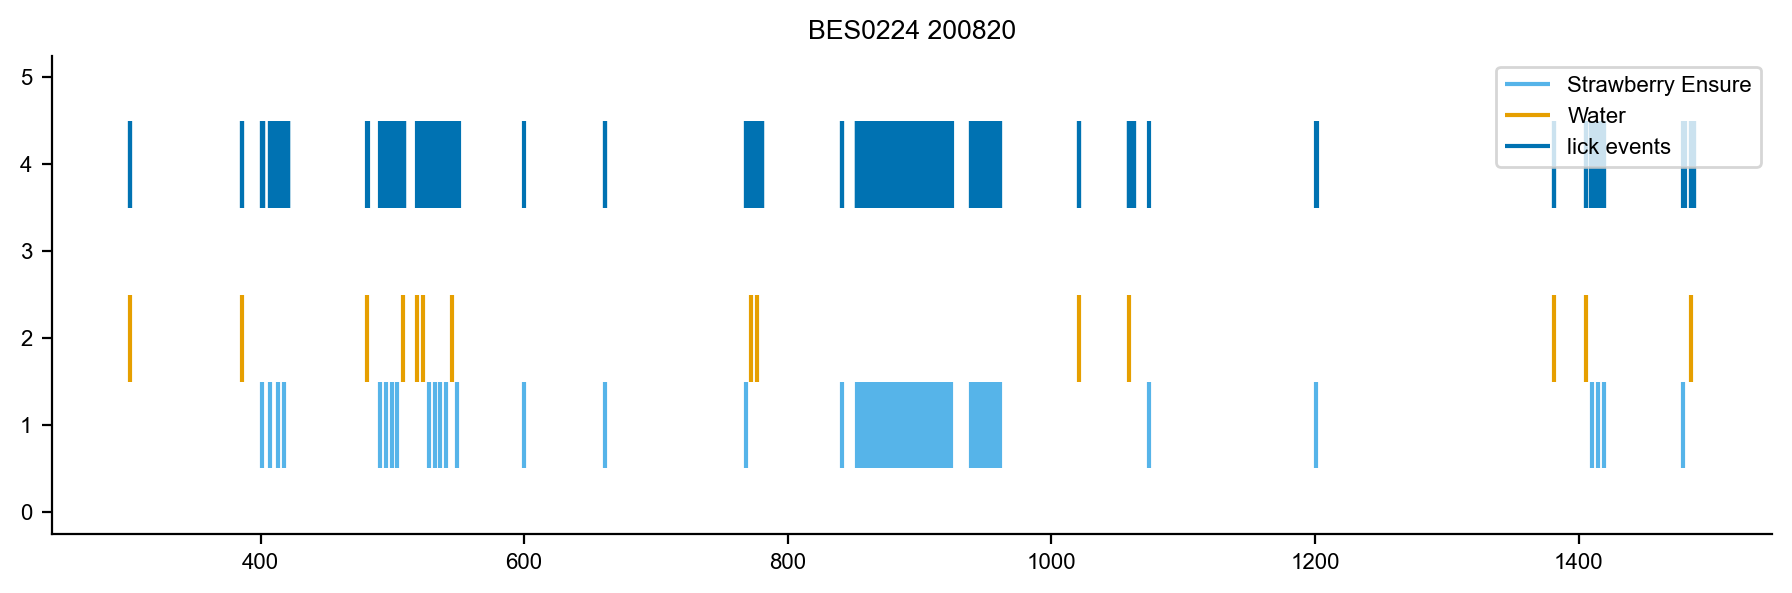

In [6]:
P1_time, P1C_time, P1D_time, Pump_all = Pump_event_calculate_P1_all(phenosys_file)

L1_timestamps_new, L2_timestamps_new, all_lick_events = lick_event_calculate(phenosys_file)

plt.figure(figsize=[9,3])
plt.title(f"{mouse_id} {date}")
plt.eventplot(P1_time,color=my_color_map[0],label=flavor_dict['P1'])
plt.eventplot(P1C_time,lineoffsets=2,color=my_color_map[1],label=flavor_dict['P1C'])

plt.eventplot(L1_timestamps_new,lineoffsets=4,color=my_color_map[4],label='lick events')

plt.legend()
sns.despine()
plt.tight_layout()



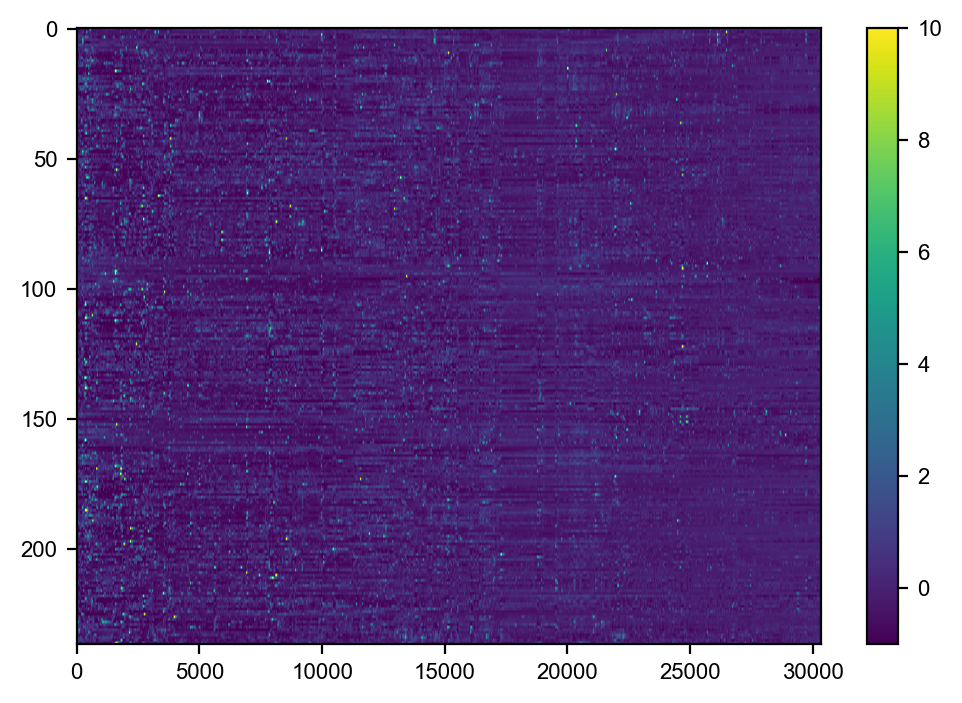

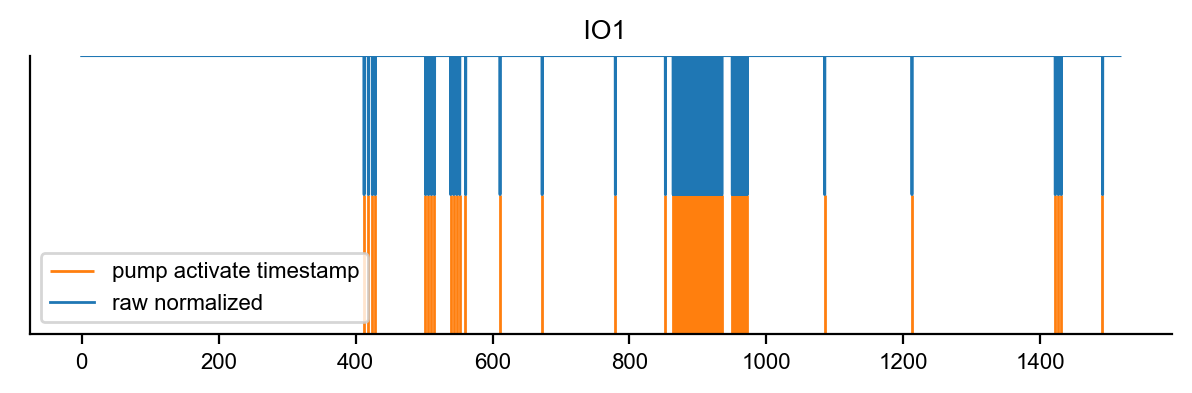

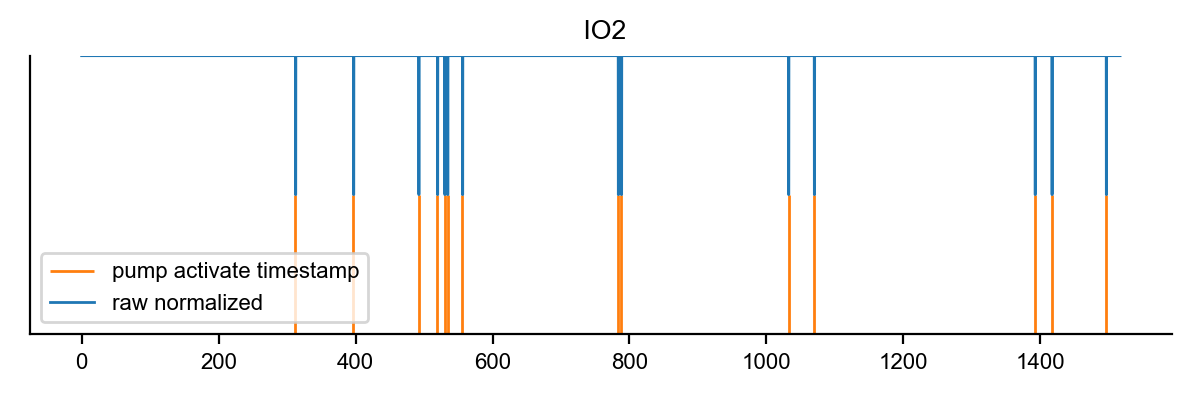

time_difference = -11.085000000000008


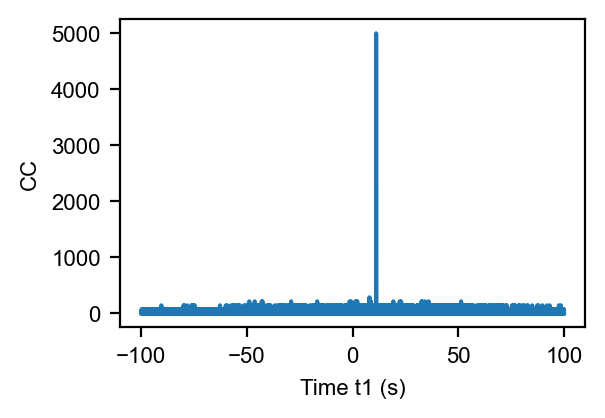

In [7]:
## load Ca2+ csv

## this example mouse Ca2+ traces were processed in smaller patches so it got better motion correction. 

extension = 'csv'
os.chdir(os.path.join(csv_folder,mouse_id))
results = sorted(glob.glob('*.{}'.format(extension)))
results = [f for f in results if date in f]
results = [f for f in results if 'celltraces.csv' in f]

df_merged = pd.DataFrame([])
for patch in results:
    patch_num = '_'+str(patch.split('_')[1])
    df_all = pd.read_csv(os.path.join(csv_folder,mouse_id,patch),header=[0,1],index_col=0)
    # Selecet only the accepted cells
    df_accepted = df_all.xs(' accepted',level='Time(s)/Cell Status',axis=1)
    df_accepted.columns = [str(col) + patch_num for col in df_accepted.columns]
    df_merged[df_accepted.columns] = df_accepted
df_accepted = pd.DataFrame([])
df_accepted = df_merged.copy()

def downsample(df_accepted):
    ## add a condition here to check if it's already 10 hz
    from math import isclose
    a = df_accepted.index[1]-df_accepted.index[0] # get diff
    b = 0.05
    print(f'frame diff: {round(a,5)}')
    if isclose(a, b, abs_tol=1e-3):
        print('20 Hz -> 10 Hz')
        from scipy import signal
        sample_num = int(df_accepted.shape[0]/2)
        df_downsampled =  pd.DataFrame(signal.resample(df_accepted, sample_num),index=df_accepted.index[::2][0:sample_num],columns=df_accepted.columns)
        return df_downsampled
    else:
        print('already 10 Hz')
        return df_accepted

# df_accepted = downsample(df_accepted)
df_accepted = correct_baseline_modploy(df_accepted)

from scipy import stats
df_z = df_accepted.apply(stats.zscore,axis=0)


vmax,vmin=10,-1

plt.figure(figsize=[6,4])
plt.imshow(df_z.T,aspect='auto',vmax=vmax,vmin=vmin)
plt.colorbar()

df_GPIO = pd.read_csv('/Users/hunglo/Documents/inscopix_csv/Ca2_csv/BES0224/BES0224200820_GPI_short.csv', header=[0], index_col=0)

def extract_GPIO_trace(df_GPIO,plot=False):
    """
    Extract GPIO traces and binarized them to timestamps
    """
    GPIO_channel_list = [name for name in df_GPIO[' Channel Name'].unique() if 'IO' in name]
    ## this should extract both GPIO or IO prefix in difference nVista system
    gpio_pump_time_all = {}
    for channel in GPIO_channel_list:
        gpio_value = df_GPIO.loc[df_GPIO[' Channel Name'] == channel][' Value'].astype(float)
        # print(channel)
        ## check if there is signal at all
        if gpio_value.max()/(gpio_value.min()+1e-8) > 2: # prevent min is 0
            gpio_norm = (gpio_value-gpio_value.min())/(gpio_value.max()-gpio_value.min())
            gpio_timestamps = np.concatenate([np.zeros(1),gpio_norm[gpio_norm<0.5].index],axis=0)
            gpio_time_diff = np.diff(gpio_timestamps)
            gpio_pump_time = gpio_timestamps[1:][gpio_time_diff>0.04]
            gpio_pump_time_all[channel] = gpio_pump_time
            # print(f'First pump time: {gpio_pump_time_all[channel][0]}')

            if plot:
                plt.figure(figsize=[6,2])
                plt.title(channel)
                plt.eventplot(gpio_pump_time_all[channel],colors='C1',lineoffsets=-0.5,linewidths=1,label='pump activate timestamp')
                plt.plot(gpio_norm,lw=1,label='raw normalized')
                plt.legend()
                plt.yticks([])
                plt.ylim([-1,1])
                sns.despine()
                plt.tight_layout()
                # plt.xlim([300,350])
                # plt.xlim([410,420])
                plt.show()
        else:
            # print(f'No inputs in{channel} channel, skipped\n')
            # print(channel)
            pass
    ## Check if GPIO signals are missing, if so add an empty np array to the corresponding channel:
    # print(f'chan #{len(gpio_pump_time_all.keys())}')
    if len(gpio_pump_time_all.keys())==1:
        if ' GPIO-1' in gpio_pump_time_all.keys():
            gpio_pump_time_all[' GPIO-2'] = np.array([])
        elif ' IO1' in gpio_pump_time_all.keys():
            gpio_pump_time_all[' IO2'] = np.array([])
        elif ' IO2' in gpio_pump_time_all.keys():
            gpio_pump_time_all[' IO1'] = np.array([])
        elif ' GPIO-3' in gpio_pump_time_all.keys():
            gpio_pump_time_all[' GPIO-4'] = np.array([])
    ## simplify GPIO channel to just GPIO1 & 2
    keys = gpio_pump_time_all.keys()
    # print(f'chan #{len(gpio_pump_time_all.keys())}')
    # GPIO_pool = []
    for idx,key in enumerate(keys):
      # print(idx,key)
      # print(gpio_pump_time_all.get(key))
    #   GPIO_pool.append(np.min(gpio_pump_time_all[key]))
      if idx ==0:
        GPIO_pump1 = gpio_pump_time_all[key]
      else:
        GPIO_pump2 = gpio_pump_time_all[key]
    GPIO_pump1_clean, GPIO_pump2_clean, GPIO_pump_all_no_init = remove_isx_GPIO_init(GPIO_pump1,GPIO_pump2)
    # GPIO_min = np.min(GPIO_pump_all_no_init)
    # print(len(GPIO_pump1_clean), len(GPIO_pump2_clean))

    return GPIO_pump1_clean, GPIO_pump2_clean, GPIO_pump_all_no_init

def remove_isx_GPIO_init(Pump1,Pump2):
  pump_all = [*Pump1,*Pump2]
  pump_all = sorted(pump_all)
  ## remove all pump event in 300 sec, since there shouldn't be any
  pump_all = [i for i in pump_all if i >= 300]
  pump_all = np.array(pump_all)
  x_shift_end = pump_all[-1]
  x_shift_start = pump_all[0] -120 # force the x_bar to start at the beginning of this round
  x_bar = [x*180+300 for x in range(18)]
  # x_bar = [0] + x_bar
  x_bar = np.array(x_bar)
  x_bar = x_bar[x_bar<x_shift_end]
  x_bar = x_bar[x_bar>x_shift_start]
  Pump1 = np.array(Pump1)
  Pump2 = np.array(Pump2)
  for x in x_bar:
    if find_nearest(pump_all[pump_all>x],x)-x>25: # this means there is no initial pulse within 3 sec at the round starting time
       pass
    else:
      if len(Pump2[Pump2>x]) == 0: ## prevent the 2nd pump is empty
        if len(Pump1[Pump1>x]) == 0:
          #  print('no event in this range, skip')
          pass
        else:
          nearest_num = [find_nearest(Pump1[Pump1>x],x)]
          if find_nearest(nearest_num,x) in Pump1:
            Pump1 = np.delete(Pump1, np.where(Pump1 == find_nearest(nearest_num,x)))
            # print(f'{x}, del {find_nearest(nearest_num,x)} from Pump1 isx')
      else:
        if len(Pump1[Pump1>x]) == 0:
          nearest_num = [find_nearest(Pump2[Pump2>x],x)]
          Pump2 = np.delete(Pump2, np.where(Pump2 == find_nearest(nearest_num,x)))
          # print(f'{x}, del {find_nearest(nearest_num,x)} from Pump2 isx')
        else:
          nearest_num = [find_nearest(Pump1[Pump1>x],x),find_nearest(Pump2[Pump2>x],x)]
          if find_nearest(nearest_num,x) in Pump1:
            Pump1 = np.delete(Pump1, np.where(Pump1 == find_nearest(nearest_num,x)))
            # print(f'{x}, del {find_nearest(nearest_num,x)} from Pump1 isx')
          elif find_nearest(nearest_num,x) in Pump2:    
            Pump2 = np.delete(Pump2, np.where(Pump2 == find_nearest(nearest_num,x)))
            # print(f'{x}, del {find_nearest(nearest_num,x)} from Pump2 isx')
  Pump_all_no_init = [*Pump1,*Pump2]
  Pump_all_no_init = np.array(sorted(Pump_all_no_init))
  return Pump1,Pump2,Pump_all_no_init

## find nearst value in np array
def find_nearest(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return array[idx]

GPIO_pump1_clean, GPIO_pump2_clean, GPIO_pump_all_no_init = extract_GPIO_trace(df_GPIO,plot=True)

## align data frames

## align with all GPIO and P1D and P1C phenosys
P1_P1C_time = np.concatenate([P1C_time,P1_time],axis=0)
P1_P1C_time = np.array(sorted(P1_P1C_time))

GPIO_pump_all_no_init

def get_time_difference(PAll,GPIO_pump_all_no_init,windowsize=100):
    """
    This is the current one I used now, use the pynapple cross-correlogram funciton, I can get the time difference without fully matching the timestamps
    """
    if len(PAll) <2:
      print('no enough drinking events')
      time_difference = 0
    else:
      ts1 = nap.Ts(np.array(PAll))
      ts2 = nap.Ts(np.array(GPIO_pump_all_no_init))

      binsize=0.001
      tsgroup = nap.TsGroup({0:ts1,1:ts2})
      cross_corr = nap.compute_crosscorrelogram(tsgroup,binsize=binsize,windowsize=windowsize)
      lag = cross_corr.idxmax().values # the index of max value
      # print(f'time difference: {lag[0]}')
      time_difference = -lag[0] # set to negative
      plt.figure(figsize=[3,2])
      plt.plot(cross_corr)
      plt.xlabel("Time t1 (s)")
      plt.ylabel("CC")
    return time_difference 

time_difference = get_time_difference(P1_P1C_time,GPIO_pump_all_no_init)

print(f'{time_difference = }')

df_z.index = df_z.index+time_difference



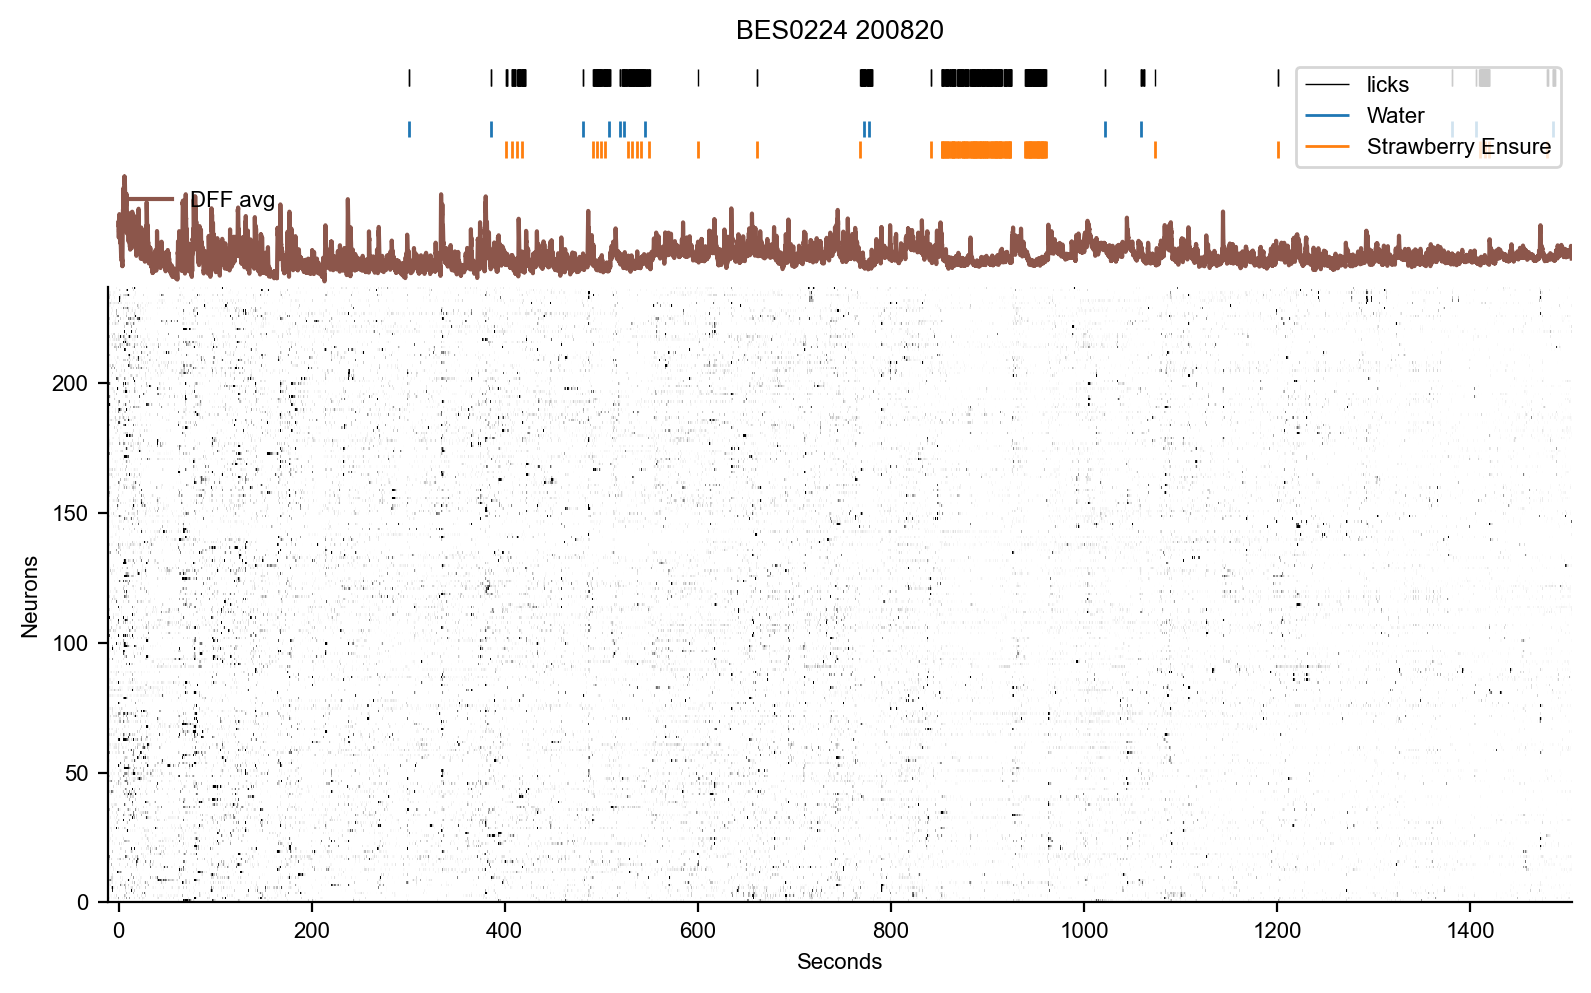

In [8]:
## plot without sorting

fig, axes = plt.subplots(figsize=[8,5],gridspec_kw={'height_ratios':[1.5,1.5,8],'hspace':0.0},nrows=3,sharex=True)

vmax=8 # cap the upper limit for color map
vmin=0.5
extent = [df_z.index[0],df_z.index[-1],0,df_z.shape[1]] # make the axis label readable
axes[2].imshow(df_z.T,aspect='auto',extent=extent,vmax=vmax,vmin=vmin,cmap='Greys',interpolation='none')

## plot pump events with with shift in y position
ymax = df_z.shape[1]
axes[0].eventplot(L1_timestamps_new,color=['k'],lineoffsets=4.5,linelengths=0.8,linewidths=0.5)
axes[0].eventplot([P1C_time,P1_time],lineoffsets=[2,1],color=['C0','C1'],linelengths=0.8,linewidths=1)

axes[1].plot(df_z.mean(axis=1)[0:],color='C5',label='DFF avg',lw=1.5)
axes[0].legend(['licks',flavor_dict['P1C'],flavor_dict['P1']],frameon=True,fontsize=8)
axes[1].legend(frameon=False,loc=2)

axes[0].axis('off')
axes[1].axis('off')
axes[2].set_xlabel('Seconds')
axes[2].set_ylabel('Neurons')
axes[0].set_title(f"{mouse_id} {date}")
sns.despine(ax=axes[2])
plt.tight_layout()


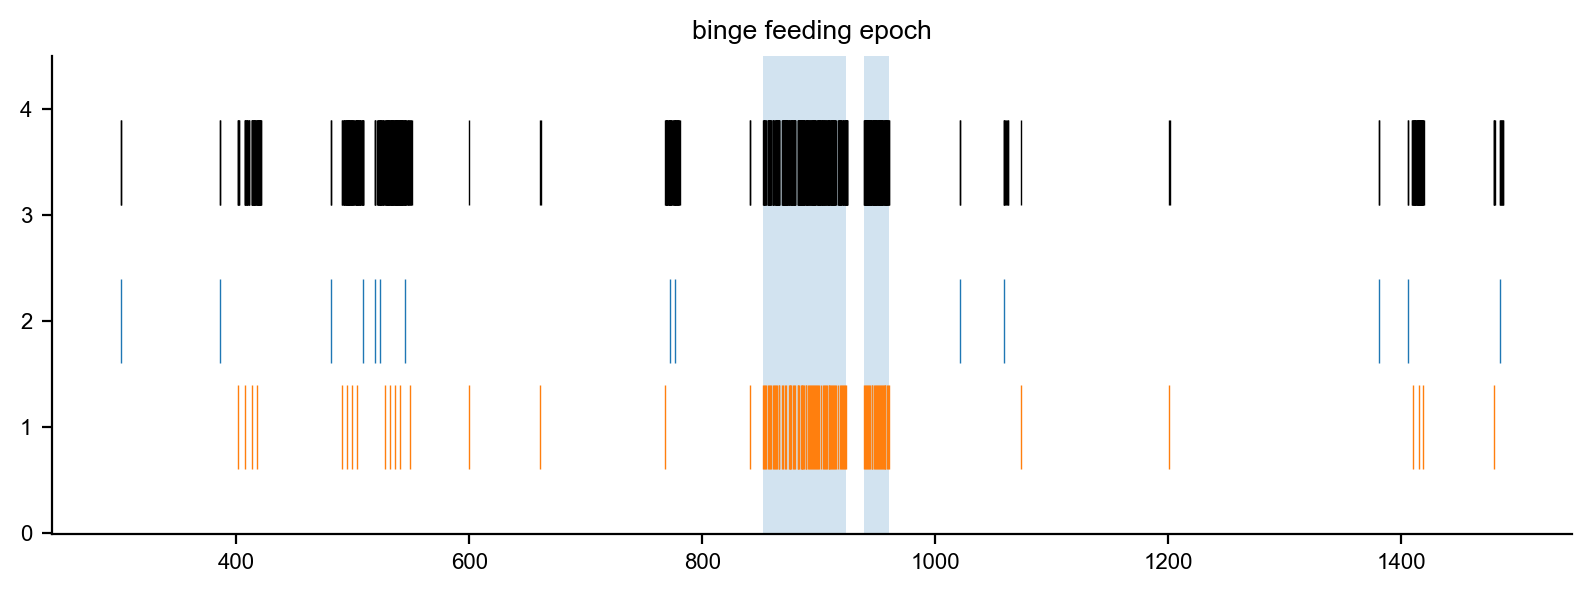

In [9]:
## run binge detection on P1D+P1C together, which will give us the overall feeding rate

interval = 3.5
binge_epoch, not_binge_epoch = [],[]

binge_df, binge_epoch = detect_binge_bout(Pump_event=P1_P1C_time,
                            n_pumps = 3, # min of pump events in one binge bout  
                            max_isi = interval,
                            min_ibi = interval)
# binge_epoch

binge_epoch = binge_epoch.drop_short_intervals(3)

## function for converting intervalset to pandas dataframe
def intervalset2pd(intervalset):
    return pd.DataFrame(data=intervalset.values,columns=intervalset.columns)
def pd2intervalset(pd):
    return nap.IntervalSet(start=pd['start'].values,end=pd['end'].values)

# binge_epoch = intervalset2pd(binge_epoch)
# binge_epoch = pd.DataFrame(binge_epoch)
# binge_epoch = binge_epoch.as_dataframe()

plt.figure(figsize=[8,3])
plt.eventplot(L1_timestamps_new,color=['k'],lineoffsets=3.5,linelengths=0.8,linewidths=0.5)
plt.eventplot([P1C_time,P1_time],lineoffsets=[2,1],color=['C0','C1'],linelengths=0.8,linewidths=0.5)

for i in range(len(binge_epoch)):
    plt.axvspan(xmin=binge_epoch.start[i],xmax=binge_epoch.end[i],alpha=0.2)
sns.despine()
plt.title('binge feeding epoch')
plt.tight_layout()



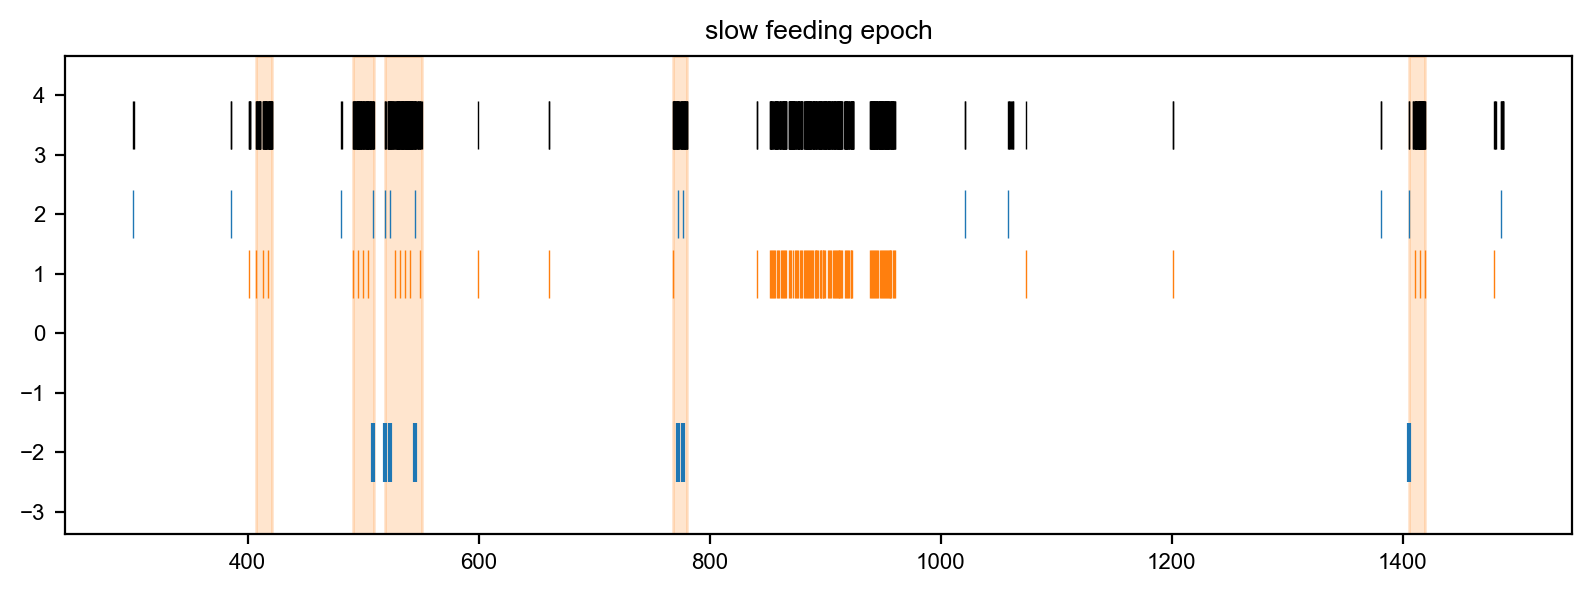

In [10]:
## take out binge bouts from pump events so we have only sloww feeding events left.

interval = 4
lick_df, lick_epoch = detect_binge_bout(Pump_event=L1_timestamps_new,
                                        n_pumps = 3, # min of pump events in one binge bout  
                                        max_isi = interval,
                                        min_ibi = interval)
binge_epoch
lick_epoch = lick_epoch.set_diff(binge_epoch)
## remove epoch smaller than 1 seconds?
lick_epoch = intervalset2pd(lick_epoch)
lick_epoch['duration'] = lick_epoch['end']- lick_epoch['start']
lick_epoch = lick_epoch[lick_epoch['duration']>4]
lick_epoch = pd2intervalset(lick_epoch)
lick_epoch

plt.figure(figsize=[8,3])
plt.eventplot(L1_timestamps_new,color=['k'],lineoffsets=3.5,linelengths=0.8,linewidths=0.5)
plt.eventplot([P1C_time,P1_time],lineoffsets=[2,1],color=['C0','C1'],linelengths=0.8,linewidths=0.5)

for i in range(len(lick_epoch)):
    plt.axvspan(xmin=lick_epoch.start[i],xmax=lick_epoch.end[i],alpha=0.2,color='C1')

plt.eventplot(nap.Ts(P1D_time).restrict(lick_epoch).index,lineoffsets=-1) # this is ensure slow timestamps
plt.eventplot(nap.Ts(P1C_time).restrict(lick_epoch).index,lineoffsets=-2) # this is diluted ensure slow timestamps
plt.title('slow feeding epoch')
plt.tight_layout()
# plt.xlim([900,920])

In [11]:
## get pump events only during slow feeding/licking epoch

P1C_slow_ts = nap.Ts(P1C_time).restrict(lick_epoch).index
P1_slow_ts  = nap.Ts(P1_time).restrict(lick_epoch).index

# remove trials where there is no lick events after pump delivery
P1C_slow_ts_clean  = slow_feeding_event_clean_up(slow_milk_ts=P1C_slow_ts, lick_event=L1_timestamps_new)
P1_slow_ts_clean   = slow_feeding_event_clean_up(slow_milk_ts=P1_slow_ts, lick_event=L1_timestamps_new)

# do baseline alignment
aligned_window = 1 # sec

## do PETH with nap functions
## compute peri-event with nap function

## align baseline for each trials
def align_peth(nap_peth,start=-1,end=0):
    data = nap_peth.values
    t = nap_peth.t
    data = nap_peth.copy().values
    t = nap_peth.t
    for cell in range(data.shape[2]):
        for trial in range(data.shape[1]):
            data[:,trial,cell] -= data[(t>start)&(t<end),trial,cell].mean(axis=0) # align baseline to 0 for each trial

    nap_peth_new = nap.TsdTensor(d=data,t=t)
    return nap_peth_new

minmax = (-5,5)
aligned_window_start = -aligned_window
aligned_window_end = 0

P1_peth_nap            = align_peth(nap.compute_perievent_continuous(nap.TsdFrame(t=df_z.index,d=df_z.values), tref=nap.Ts(P1_slow_ts_clean),minmax=minmax),     start=aligned_window_start,end=aligned_window_end)
P1C_peth_nap           = align_peth(nap.compute_perievent_continuous(nap.TsdFrame(t=df_z.index,d=df_z.values), tref=nap.Ts(P1C_slow_ts_clean),minmax=minmax),    start=aligned_window_start,end=aligned_window_end)
P1_binge_peth_nap      = align_peth(nap.compute_perievent_continuous(nap.TsdFrame(t=df_z.index,d=df_z.values), tref=nap.Ts(binge_epoch.start),minmax=minmax),start=aligned_window_start,end=aligned_window_end)
lick_peth_nap          = align_peth(nap.compute_perievent_continuous(nap.TsdFrame(t=df_z.index,d=df_z.values), tref=nap.Ts(lick_epoch.start),minmax=minmax),    start=aligned_window_start,end=aligned_window_end)


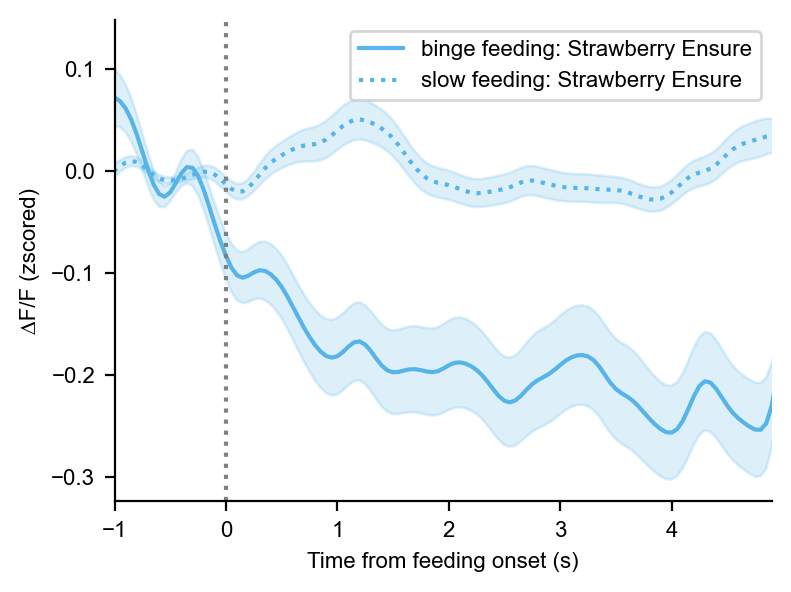

In [12]:
## function for converting nap peth object to long data in pd.DataFrame for seaborn plotting

def nap_peth2longdf(nap_peth):
    if len(nap_peth.shape)==3:
        df_ = pd.DataFrame(nap_peth.d.mean(axis=1).T, columns=nap_peth.t)
    else:
        df_ = pd.DataFrame(nap_peth.d.T, columns=nap_peth.t)

    df_long = pd.melt(df_.reset_index(),id_vars='index',value_name='zs-dff',var_name='Time (sec)')
    return df_long


fig, ax = plt.subplots(figsize=[4,3])
sns.lineplot(nap_peth2longdf(P1_binge_peth_nap.smooth(std=0.1)),x='Time (sec)',y='zs-dff',errorbar='se',label=f'binge feeding: {flavor_dict["P1"]}',color=my_color_map[0],ax=ax)
sns.lineplot(nap_peth2longdf(P1_peth_nap.smooth(std=0.1)),x='Time (sec)',y='zs-dff',errorbar='se',label=f'slow feeding: {flavor_dict["P1"]}',color=my_color_map[0],ax=ax,ls=':')

plt.xlim([-1,4.9])
plt.axvline(x=0,ls=':',color='grey')
plt.ylabel('∆F/F (zscored)')
plt.xlabel('Time from feeding onset (s)')
sns.despine()
plt.tight_layout()

In [13]:
## Calculate auROC for classifying neurons into classes

def cal_auroc_nap(PETH, baseline_window=1,steps=20):
  """
  PETH: 3D np array of neuronal matrix, ordered with time, trials, neurons (nap.TsdTensor order)
  baseline_window: * sec before pump delivery, default is 1 sec

  """
  from sklearn.metrics import auc

  auc_total_all_cell       = np.zeros((PETH.shape[2],PETH.shape[0]))
  frate = 10 # all 10 Hz

  data = PETH.d
  for idx in range(data.shape[2]):
        if idx%50==0:
          print(f'now at neuron: {idx}')
        
        baseline = data[50-baseline_window*frate:50,:,idx].flatten()
        auc_total = []
        for i in range(data.shape[0]):
          stimulus = data[i,:,idx]
          pool = [*baseline, *stimulus]
          steps = steps
          criteria = [min(pool) + (j*(max(pool)-min(pool))/steps) for j in range(steps)]
          criteria[0] = criteria[0] - 1e-12 # modify the min value to slighter lesser value, so baseline/stimulus will be larger than the min of criteria
          pbase, pstim = [],[]
          # Calculate P(above threshold) for each cutoff
          for cri in criteria:
            pbase.append(sum(baseline > cri)/len(baseline))
            pstim.append(sum(stimulus > cri)/len(stimulus))
          auc_ = auc(x = pbase, y = pstim)
          auc_total.append(auc_)
        auc_total_all_cell[idx,:] = auc_total

  return auc_total_all_cell

auroc_P1  = cal_auroc_nap(P1_peth_nap)
auroc_P1C = cal_auroc_nap(P1C_peth_nap)

now at neuron: 0
now at neuron: 50
now at neuron: 100
now at neuron: 150
now at neuron: 200
now at neuron: 0
now at neuron: 50
now at neuron: 100
now at neuron: 150
now at neuron: 200


In [14]:
## make a classification function here based on auROC
def checkConsecutive(l,n=3):
    n = n-1 # diff will be one less than all elements in the list
    return (sum(np.diff(sorted(l)) == 1) >= n) 

def cell_class(auroc,window=2,threshold_sd=2):
   idx_positive = []
   idx_negative = []
   frate = 10
   for idx in range(auroc.shape[0]):
    threshold_high = np.mean(auroc[idx,40:50]) + np.std(auroc[idx,40:50])*threshold_sd
    auroc_temp = auroc[idx].copy()
    j_temp = []
    for j in range(50,50+int(window*frate)):  # Only look at first 2 sec after delivery (the window size)
        if auroc_temp[j] > threshold_high:
           j_temp.append(j)
    if j_temp !=[]:
        if checkConsecutive(j_temp,n=3) == True:
           idx_positive.append(idx)
      # print('# {} is responding to milk'.format(idx))
   for idx in range(auroc.shape[0]):
    threshold_high = np.mean(auroc[idx,40:50]) - np.std(auroc[idx,40:50])*threshold_sd
    auroc_temp = auroc[idx].copy()
    j_temp = []
    for j in range(50,50+int(window*frate)):  # Only look at first 2 sec after delivery (the window size)
        if auroc_temp[j] < threshold_high:
           j_temp.append(j)
    if j_temp !=[]:
        if checkConsecutive(j_temp,n=3) == True:
           idx_negative.append(idx)
      # print('# {} is responding to milk'.format(idx))
   ## make idx for non-responding neurons
   cellnum = auroc.shape[0]
   idx_non = []
   idx_non = [i for i in range(cellnum) if i not in idx_positive and i not in idx_negative]
   return idx_positive, idx_negative, idx_non

food_idx_pos, food_idx_neg, food_idx_non    = cell_class(auroc_P1)
water_idx_pos, water_idx_neg, water_idx_non = cell_class(auroc_P1C)




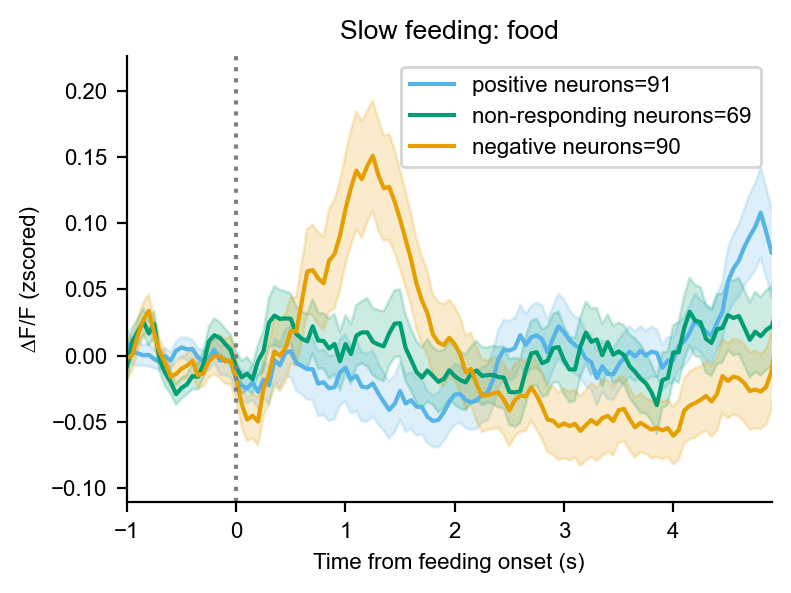

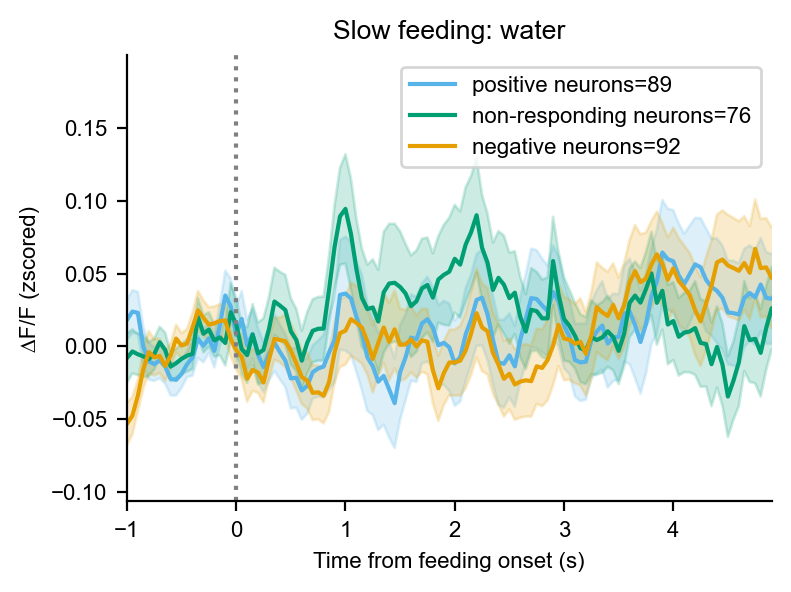

In [15]:
food_idx_pos_only   = [idx for idx in food_idx_pos if idx not in water_idx_pos]
water_idx_pos_only  = [idx for idx in water_idx_pos if idx not in food_idx_pos]
both_idx_pos        = [idx for idx in water_idx_pos if idx in food_idx_pos]
other_idx           = [idx for idx in np.arange(auroc_P1C.shape[0]) if (idx not in food_idx_pos) and (idx not in water_idx_pos)]


# plot slow feeding with different neuron responding types

fig, ax = plt.subplots(figsize=[4,3])
sns.lineplot(nap_peth2longdf(P1_peth_nap[:,:,food_idx_pos]),x='Time (sec)',y='zs-dff',errorbar='se',label=f'positive neurons={len(food_idx_pos)}',color=my_color_map[0])
sns.lineplot(nap_peth2longdf(P1_peth_nap[:,:,food_idx_non]),x='Time (sec)',y='zs-dff',errorbar='se',label=f'non-responding neurons={len(food_idx_non)}',color=my_color_map[2])
sns.lineplot(nap_peth2longdf(P1_peth_nap[:,:,food_idx_neg]),x='Time (sec)',y='zs-dff',errorbar='se',label=f'negative neurons={len(food_idx_neg)}',color=my_color_map[1])
plt.title('Slow feeding: food')
plt.xlim([-1,4.9])
plt.axvline(x=0,ls=':',color='grey')
plt.ylabel('∆F/F (zscored)')
plt.xlabel('Time from feeding onset (s)')
sns.despine()
plt.tight_layout()

fig, ax = plt.subplots(figsize=[4,3])
sns.lineplot(nap_peth2longdf(P1C_peth_nap[:,:,water_idx_pos]),x='Time (sec)',y='zs-dff',errorbar='se',label=f'positive neurons={len(water_idx_pos)}',color=my_color_map[0])
sns.lineplot(nap_peth2longdf(P1C_peth_nap[:,:,water_idx_non]),x='Time (sec)',y='zs-dff',errorbar='se',label=f'non-responding neurons={len(water_idx_non)}',color=my_color_map[2])
sns.lineplot(nap_peth2longdf(P1C_peth_nap[:,:,water_idx_neg]),x='Time (sec)',y='zs-dff',errorbar='se',label=f'negative neurons={len(water_idx_neg)}',color=my_color_map[1])
plt.title('Slow feeding: water')
plt.xlim([-1,4.9])
plt.axvline(x=0,ls=':',color='grey')
plt.ylabel('∆F/F (zscored)')
plt.xlabel('Time from feeding onset (s)')
sns.despine()
plt.tight_layout()

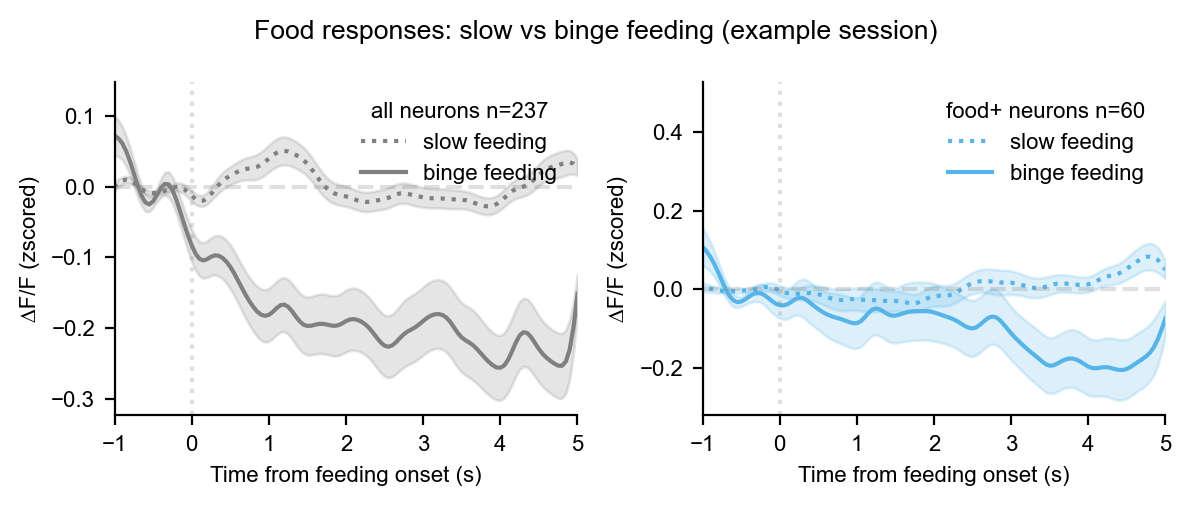

In [16]:
# plot all neurons and slow feeding responding neurons during binge feeding

fig, axes = plt.subplots(ncols=2,nrows=1,figsize=[6,2.5])
sns.lineplot(nap_peth2longdf(P1_peth_nap.smooth(0.1)),x='Time (sec)',y='zs-dff',errorbar='se',label=f'slow feeding',color=my_color_map_grey[0],ls=':',ax=axes[0])
sns.lineplot(nap_peth2longdf(P1_binge_peth_nap.smooth(0.1)),x='Time (sec)',y='zs-dff',errorbar='se',label=f'binge feeding',color=my_color_map_grey[0],ax=axes[0])
axes[0].legend(loc=1,frameon=False,title=f'all neurons n={P1_peth_nap.shape[2]}')

sns.lineplot(nap_peth2longdf(P1_peth_nap[:,:,food_idx_pos_only].smooth(0.1)),x='Time (sec)',y='zs-dff',errorbar='se',label=f'slow feeding',color=my_color_map[0],ls=':',ax=axes[1])
sns.lineplot(nap_peth2longdf(P1_binge_peth_nap[:,:,food_idx_pos_only].smooth(0.1)),x='Time (sec)',y='zs-dff',errorbar='se',label=f'binge feeding',color=my_color_map[0],ax=axes[1])
axes[1].legend(loc=1,frameon=False,title=f'food+ neurons n={len(food_idx_pos_only)}')

for i in range(2):
    axes[i].set_xlim([-1,5])
    axes[i].axvline(x=0,ls=':',color='grey',alpha=0.25)
    axes[i].axhline(y=0,ls='--',color='grey',alpha=0.25)
    axes[i].set_xlabel('Time from feeding onset (s)')
    axes[i].set_ylabel('∆F/F (zscored)')
    sns.despine(ax=axes[i])
fig.suptitle('Food responses: slow vs binge feeding (example session)')
plt.tight_layout()
plt.show()
